In [1]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from typing import Literal

In [2]:
os.getcwd()

'/home/skandabhairava/Desktop/MFT_FL/notebooks'

In [4]:
# Define your known tags (easy to expand anytime)
KNOWN_TAGS = {
    "attack_type": ["backdoor60", "backdoor40", "lblswitch60", "lblswitch40", "labelswitch60", 
                    "labelswitch40", "majoritybyz40", "majoritybyz60", "subtle40", "subtle60", "alie40", "alie60", "normal",
                    "late_lblswitch60", "late_backdoor60", "late_subtle60", "late_alie60"
                   ],
    "protocol_type": ["fedattract", "cap", "fedavg"],
    "data_type": ["pathalogical", "pathological", "d0-3", "d1", "dropout50"]
}

similar_tag = {
    "lblswitch40": "labelswitch40",
    "lblswitch60": "labelswitch60",
    "late_lblswitch60": "late_labelswitch60",
    "subtle40": "majoritybyz40",
    "subtle60": "majoritybyz60",
    "late_subtle60": "late_majoritybyz60",
}

def extract_metadata(folder_name):
    name_lower = folder_name.lower()
    meta = {}
    for category, tags in KNOWN_TAGS.items():
        found = [tag for tag in tags if tag in name_lower]
        if len(found) == 0:
            raise

        if len(found) > 1:
            found = list(sorted(found, key=lambda k: len(k), reverse=True))
        
        tag = similar_tag.get(found[0], found[0])
        # print(f"{category} -> {category2}")
        meta[category] = tag if found else "unknown"
    return meta

def parse_run_log(log_path):
    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read()

    # Client breakdown
    client_matches = re.findall(r"Client\s+\d+\s+has been assigned type:\s*([^\r\n]+)", content)
    normal_count = sum(1 for c in client_matches if c.strip() == "normal")
    total_clients = len(client_matches)
    malicious_count = total_clients - normal_count
    normal_pct = (normal_count / total_clients * 100) if total_clients > 0 else 0.0

    total_bigo_time = re.search(r"Total BigO time:\s*(\d+)", content)

    client_stats = {
        "total_clients": total_clients,
        "normal_clients": normal_count,
        "malicious_clients": malicious_count,
        "normal_pct": normal_pct,
        "malicious_pct": 100 - normal_pct if total_clients > 0 else 0.0,
        "total_bigo": total_bigo_time.group(1)
    }

    # Rounds breakdown
    rounds_data = []
    round_blocks = re.split(r"(?:\n|^)\s*(\d+)/\d+:\s*", content)
    
    if len(round_blocks) > 1:
        for i in range(1, len(round_blocks), 2):
            epoch = int(round_blocks[i])
            block = round_blocks[i + 1]

            train_time = re.search(r"Time taken to train:\s*([\d\.]+)s", block)
            bigo_time = re.search(r"Big O time:\s*(\d+)", block)
            bigo_space = re.search(r"Big O space:\s*(\d+)", block)
            algo_time = re.search(r"Time taken algorithm model:\s*([\d\.]+)", block)
            eval_acc = re.search(r"Accuracy:\s*([\d\.]+)%", block)

            rounds_data.append({
                "epoch": epoch,
                "train_time_s": float(train_time.group(1)) if train_time else None,
                "eval_accuracy": float(eval_acc.group(1)) if eval_acc else None,
                "bigo_time": int(bigo_time.group(1)) if bigo_time else None,
                "bigo_space": int(bigo_space.group(1)) if bigo_space else None,
                "algo_time_s": float(algo_time.group(1)) if algo_time else None
            })

    client_stats["final_accuracy"] = rounds_data[-1]["eval_accuracy"]
    return client_stats, pd.DataFrame(rounds_data)

def load_all_runs(root_dir="./"):
    records = []
    for entry in os.scandir(root_dir):
        if entry.is_dir() and entry.name.startswith("RUN_"):
            log_path = Path(entry.path) / "run.log"
            if log_path.exists():
                meta = extract_metadata(entry.name)
                client_stats, df_rounds = parse_run_log(log_path)
                records.append({
                    "folder_name": entry.name,
                    **meta,
                    **client_stats,
                    "df_rounds": df_rounds
                })
    return pd.DataFrame(records)

In [ ]:
# Load into memory once
DF_RUNS = load_all_runs(root_dir="../logs/")

In [5]:
DF_RUNS = pd.read_pickle('df_runs.pkl')

# DF_RUNS.to_pickle('df_runs.pkl')

In [12]:
def analyze_run(attack=None, protocol=None, data_type=None, run_index=0, steps_split_fedattract=10, late_attack_start=50, return_only=None|Literal['eval_accuracy', 'bigo', 'total_bigo', 'algo_time_s', 'final_accuracy', 'all']):
    """
    Filters runs based on chosen variables and displays stats + plots.
    Pass None to any argument to leave it unconstrained.
    """
    filtered = DF_RUNS.copy()
    
    if attack:
        filtered = filtered[filtered["attack_type"] == attack.lower()]
    if protocol:
        filtered = filtered[filtered["protocol_type"] == protocol.lower()]
    if data_type:
        filtered = filtered[filtered["data_type"] == data_type.lower()]
        
    if filtered.empty:
        print(f"No runs found matching: attack='{attack}', protocol='{protocol}', data_type='{data_type}'")
        return None
    
    if len(filtered) > 1:
        print(f"Found {len(filtered)} matching runs. Displaying run index {run_index}:")
        
    row = filtered.iloc[run_index]
    df_rounds = row["df_rounds"]

    if return_only == "eval_accuracy":
        return df_rounds["eval_accuracy"]
    elif return_only == "bigo":
        return df_rounds["bigo_time"]
    elif return_only == "total_bigo":
        return row['total_bigo']
    elif return_only == "algo_time_s":
        return row['algo_time_s']
    elif return_only == "final_accuracy":
        return row['final_accuracy']
    elif return_only == "all":
        return row

    # 1. Print Client Stats
    print("=" * 65)
    print(f"RUN: {row['folder_name']}")
    print(f"Configuration -> Attack: {row['attack_type']} | Protocol: {row['protocol_type']} | Data: {row['data_type']}")
    print("-" * 65)
    print(f"Total Clients:     {row['total_clients']}")
    print(f"Normal Clients:    {row['normal_clients']} ({row['normal_pct']:.2f}%)")
    print(f"Malicious Clients: {row['malicious_clients']} ({row['malicious_pct']:.2f}%)")
    print(f"Total BigO Time: {row['total_bigo']}")
    print(f"Final Acc: {row['final_accuracy']}%")
    print("=" * 65)

    if protocol == "fedattract":
        splits_vline_idx = list(range(0, len(df_rounds["epoch"])+1, steps_split_fedattract))[1:]
    
    # 2. Plot Epoch Metrics
    if not df_rounds.empty:
        fig, axs = plt.subplots(2, 2, figsize=(13, 7))
        fig.suptitle(f"{row['folder_name']}", fontsize=11)

        # Accuracy
        axs[0, 0].plot(df_rounds["epoch"], df_rounds["eval_accuracy"], label="Eval Acc (%)", color="teal", marker="o", markersize=3)
        axs[0, 0].set_title("Accuracy per Epoch")
        axs[0, 0].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[0, 0].axvline(split, c="g")
        if "late" in attack:
            axs[0, 0].axvline(late_attack_start, c="r")
        axs[0, 0].grid(True, linestyle=":", alpha=0.6)
        axs[0, 0].legend()

        # Big O Time
        axs[0, 1].plot(df_rounds["epoch"], df_rounds["bigo_time"], color="crimson", marker="s", markersize=3)
        axs[0, 1].set_title("Big O Time")
        axs[0, 1].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[0, 1].axvline(split, c="g")
        if "late" in attack:
            axs[0, 1].axvline(late_attack_start, c="r")
        axs[0, 1].grid(True, linestyle=":", alpha=0.6)

        # Big O Space
        axs[1, 0].plot(df_rounds["epoch"], df_rounds["bigo_space"], color="darkorange", marker="^", markersize=3)
        axs[1, 0].set_title("Big O Space")
        axs[1, 0].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[1, 0].axvline(split, c="g")
        if "late" in attack:
            axs[1, 0].axvline(late_attack_start, c="r")
        axs[1, 0].grid(True, linestyle=":", alpha=0.6)

        # Algorithm Time
        axs[1, 1].plot(df_rounds["epoch"], df_rounds["algo_time_s"], color="purple", marker="d", markersize=3)
        axs[1, 1].set_title("Algorithm Execution Time (s)")
        axs[1, 1].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[1, 1].axvline(split, c="g")
        if "late" in attack:
            axs[1, 1].axvline(late_attack_start, c="r")
        axs[1, 1].grid(True, linestyle=":", alpha=0.6)

        plt.tight_layout()
        plt.show()
        
    return row

In [7]:
[c  for c in DF_RUNS.columns]

['folder_name',
 'attack_type',
 'protocol_type',
 'data_type',
 'total_clients',
 'normal_clients',
 'malicious_clients',
 'normal_pct',
 'malicious_pct',
 'total_bigo',
 'final_accuracy',
 'df_rounds']

In [8]:
DF_RUNS.attack_type.unique().tolist()

['majoritybyz40',
 'late_majoritybyz60',
 'late_backdoor60',
 'alie40',
 'backdoor60',
 'labelswitch60',
 'backdoor40',
 'majoritybyz60',
 'labelswitch40',
 'late_alie60',
 'alie60',
 'late_labelswitch60',
 'normal']

In [9]:
DF_RUNS.protocol_type.unique().tolist()

['cap', 'fedattract', 'fedavg']

In [10]:
DF_RUNS.data_type.unique().tolist()

['d1', 'pathalogical']

RUN: RUN_Sat_Aug_22_21-03-24_2026_subtle60_fedattract_D1_100-50_split_10
Configuration -> Attack: majoritybyz60 | Protocol: fedattract | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    20 (40.00%)
Malicious Clients: 30 (60.00%)
Total BigO Time: 12662
Final Acc: 51.4%


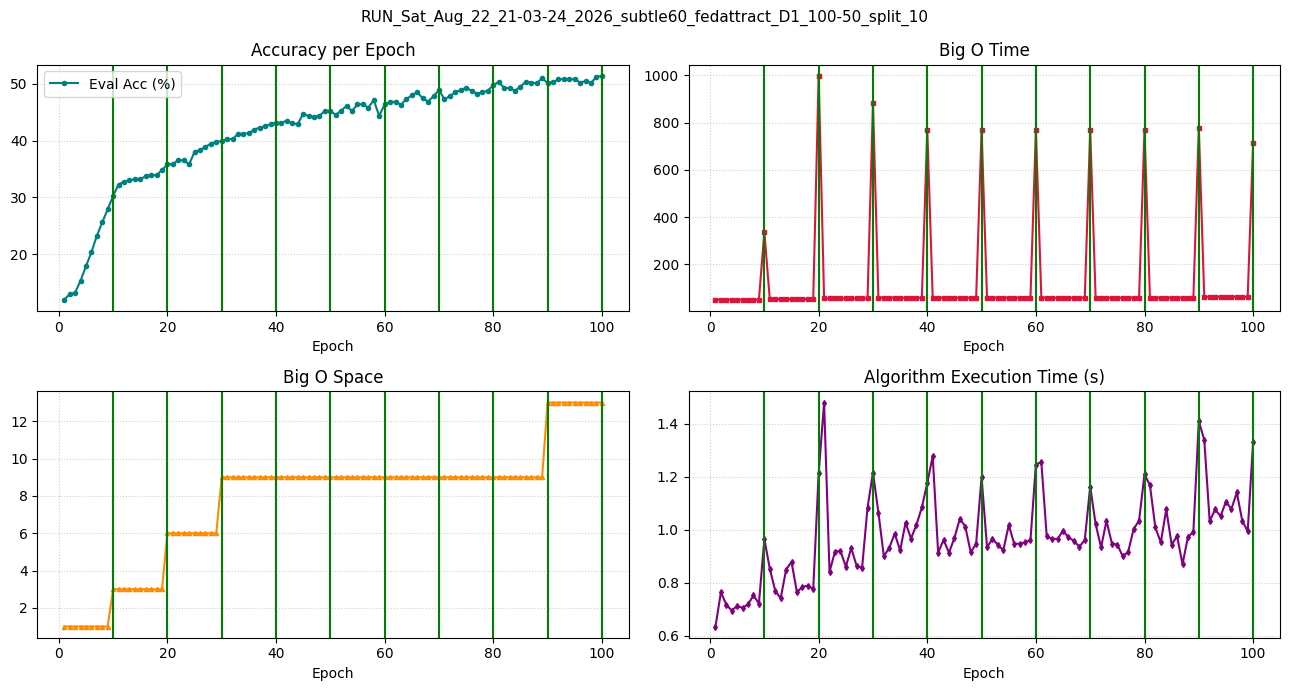

RUN: RUN_Sun_Aug_23_05-02-32_2026_subtle60_cap_D1_100-50_split_10
Configuration -> Attack: majoritybyz60 | Protocol: cap | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    20 (40.00%)
Malicious Clients: 30 (60.00%)
Total BigO Time: 108350
Final Acc: 6.07%


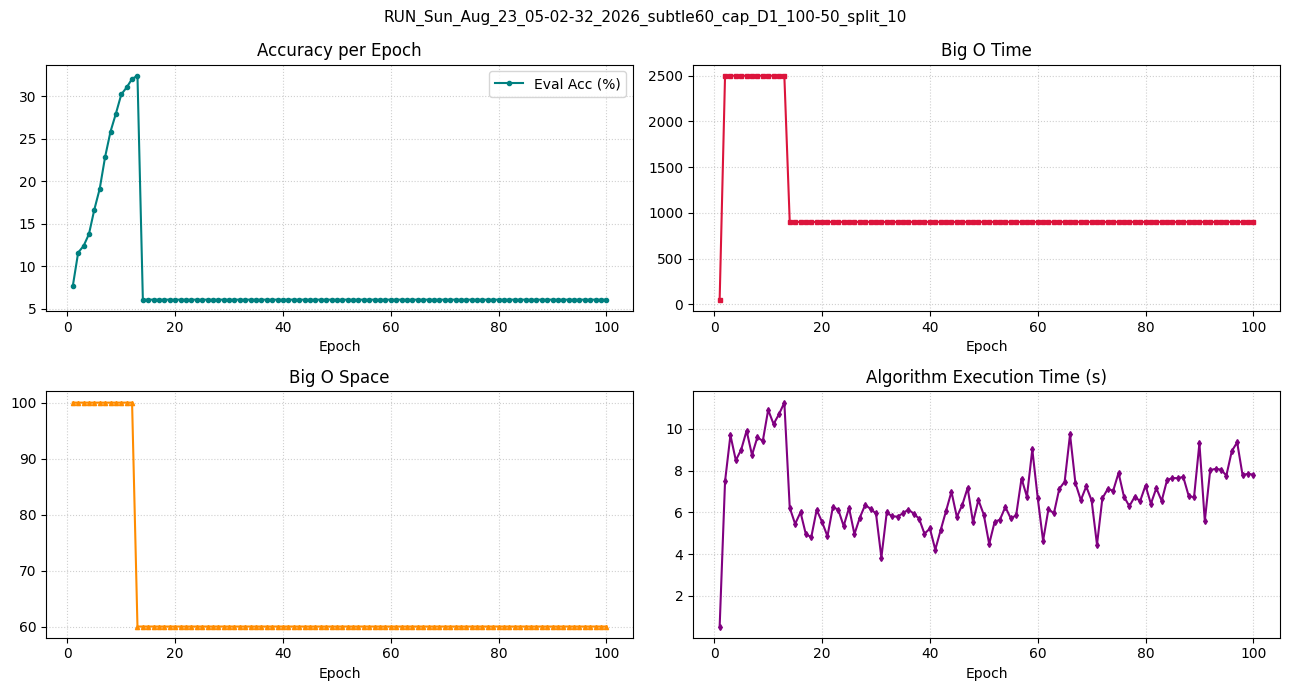

In [11]:
res1 = analyze_run(attack="majoritybyz60", protocol="fedattract", data_type="d1")
res2 = analyze_run(attack="majoritybyz60", protocol="cap", data_type="d1")

RUN: RUN_Fri_Aug_28_10-21-36_2026_alie60_fedattract_D100
Configuration -> Attack: alie60 | Protocol: fedattract | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    20 (40.00%)
Malicious Clients: 30 (60.00%)
Total BigO Time: 11110
Final Acc: 51.62%


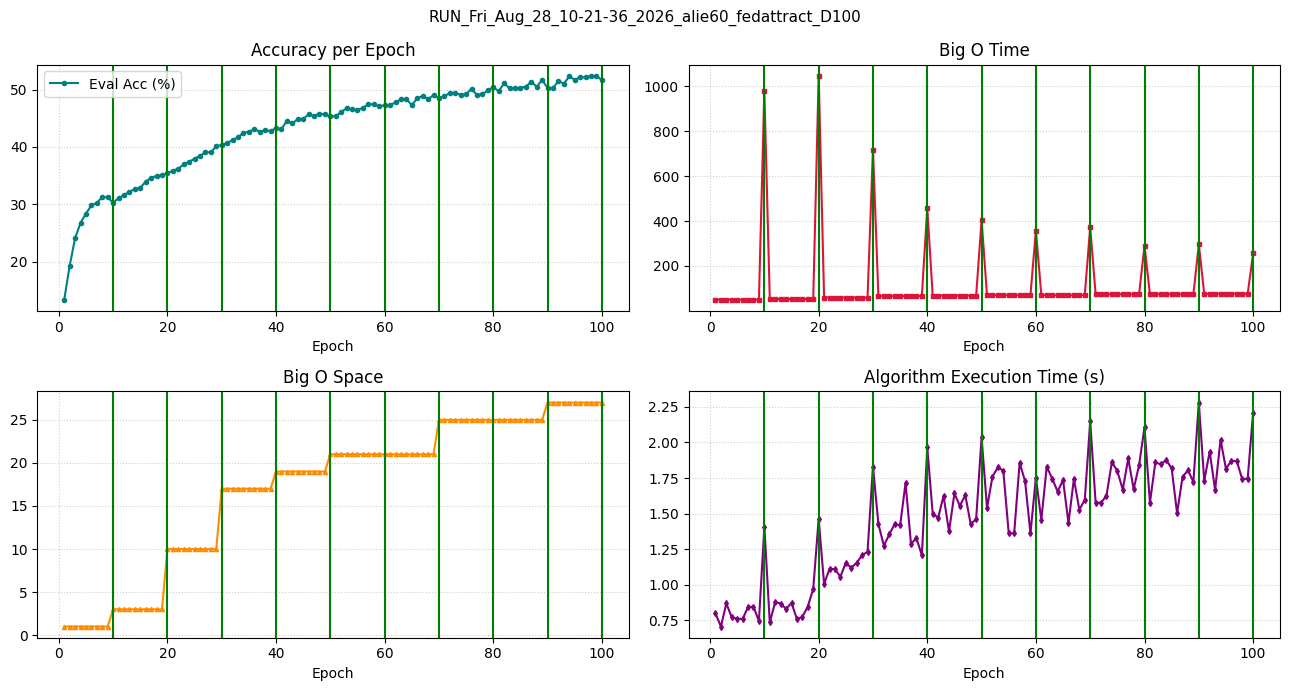

RUN: RUN_Fri_Aug_28_17-12-32_2026_alie60_cap_D100
Configuration -> Attack: alie60 | Protocol: cap | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    20 (40.00%)
Malicious Clients: 30 (60.00%)
Total BigO Time: 247550
Final Acc: 53.46%


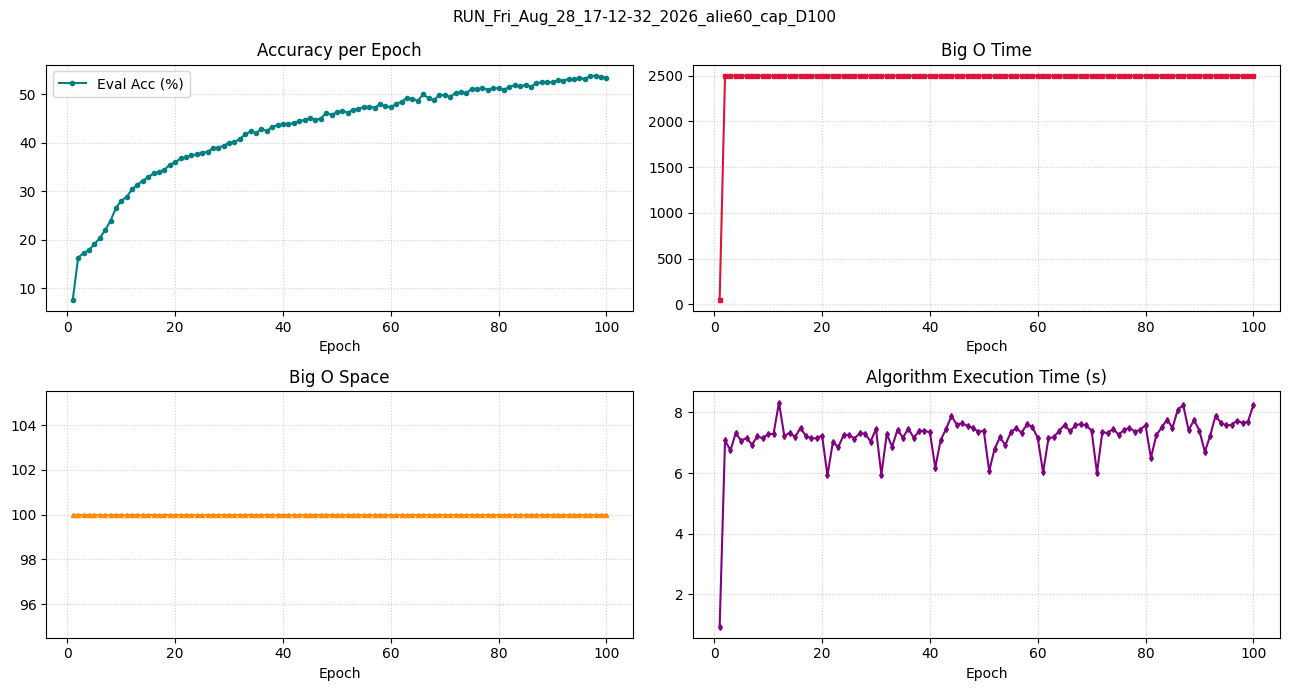

In [124]:
res1 = analyze_run(attack="alie60", protocol="fedattract", data_type="d1")
res2 = analyze_run(attack="alie60", protocol="cap", data_type="d1")

RUN: RUN_Tue_Aug_25_05-31-44_2026_labelswitch60_fedattract_D1_100-50_split_10
Configuration -> Attack: labelswitch60 | Protocol: fedattract | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    20 (40.00%)
Malicious Clients: 30 (60.00%)
Total BigO Time: 11276
Final Acc: 51.9%


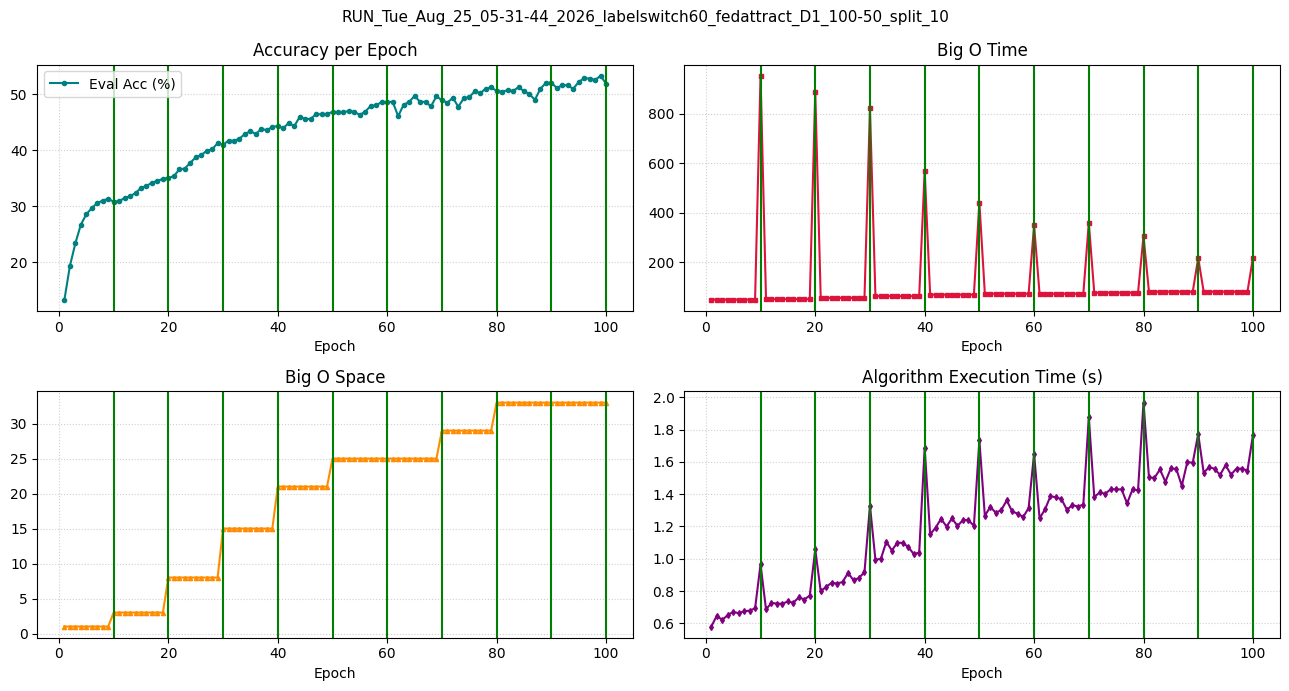

RUN: RUN_Tue_Aug_25_10-31-33_2026_labelswitch60_cap_D1_100-50_split_10
Configuration -> Attack: labelswitch60 | Protocol: cap | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    20 (40.00%)
Malicious Clients: 30 (60.00%)
Total BigO Time: 247550
Final Acc: 54.12%


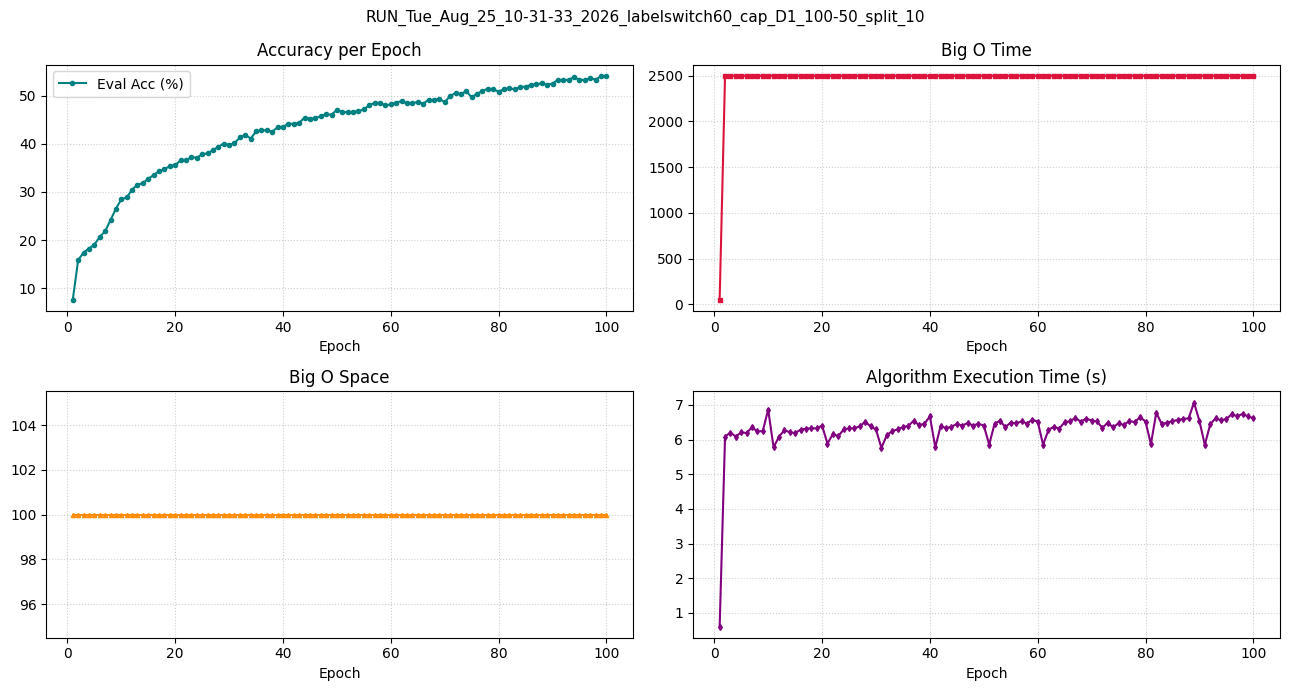

In [125]:
res1 = analyze_run(attack="labelswitch60", protocol="fedattract", data_type="d1")
res2 = analyze_run(attack="labelswitch60", protocol="cap", data_type="d1")

RUN: RUN_Sun_Aug_23_13-37-58_2026_backdoor60_fedattract_D1_100-50_split_10
Configuration -> Attack: backdoor60 | Protocol: fedattract | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    20 (40.00%)
Malicious Clients: 30 (60.00%)
Total BigO Time: 10763
Final Acc: 50.64%


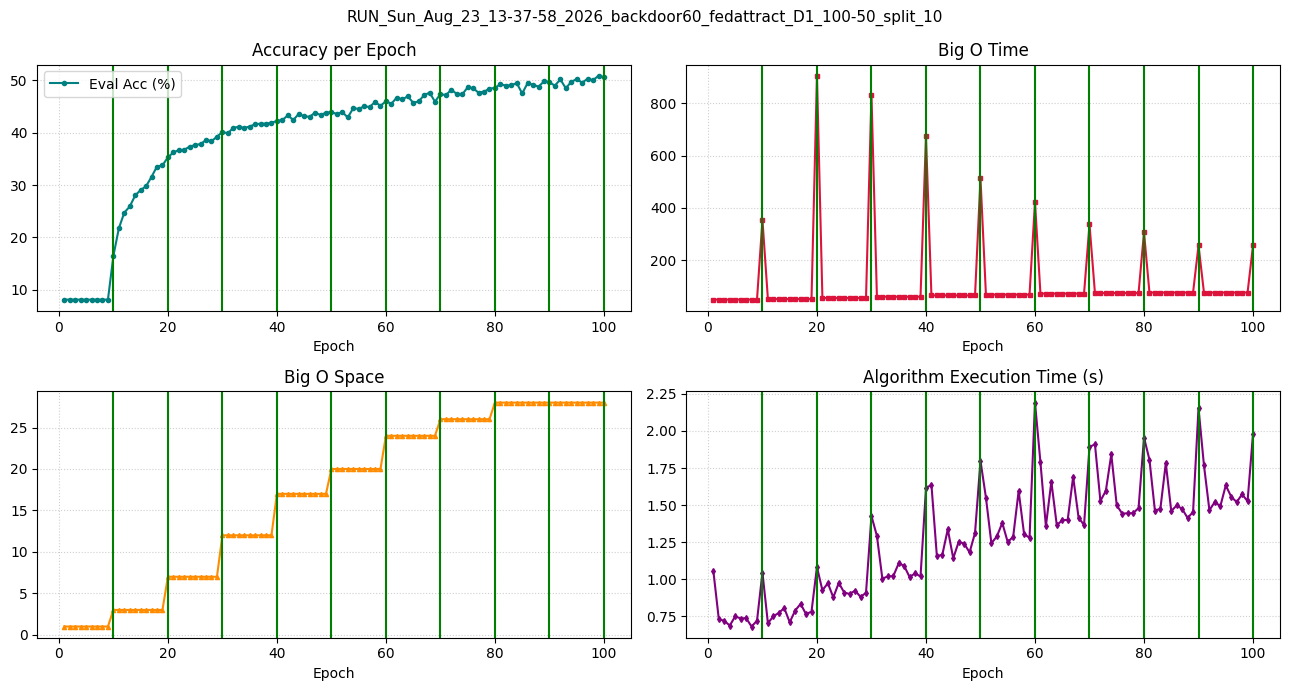

RUN: RUN_Sun_Aug_23_22-30-44_2026_backdoor60_cap_D1_100-50_split_10
Configuration -> Attack: backdoor60 | Protocol: cap | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    20 (40.00%)
Malicious Clients: 30 (60.00%)
Total BigO Time: 247550
Final Acc: 53.08%


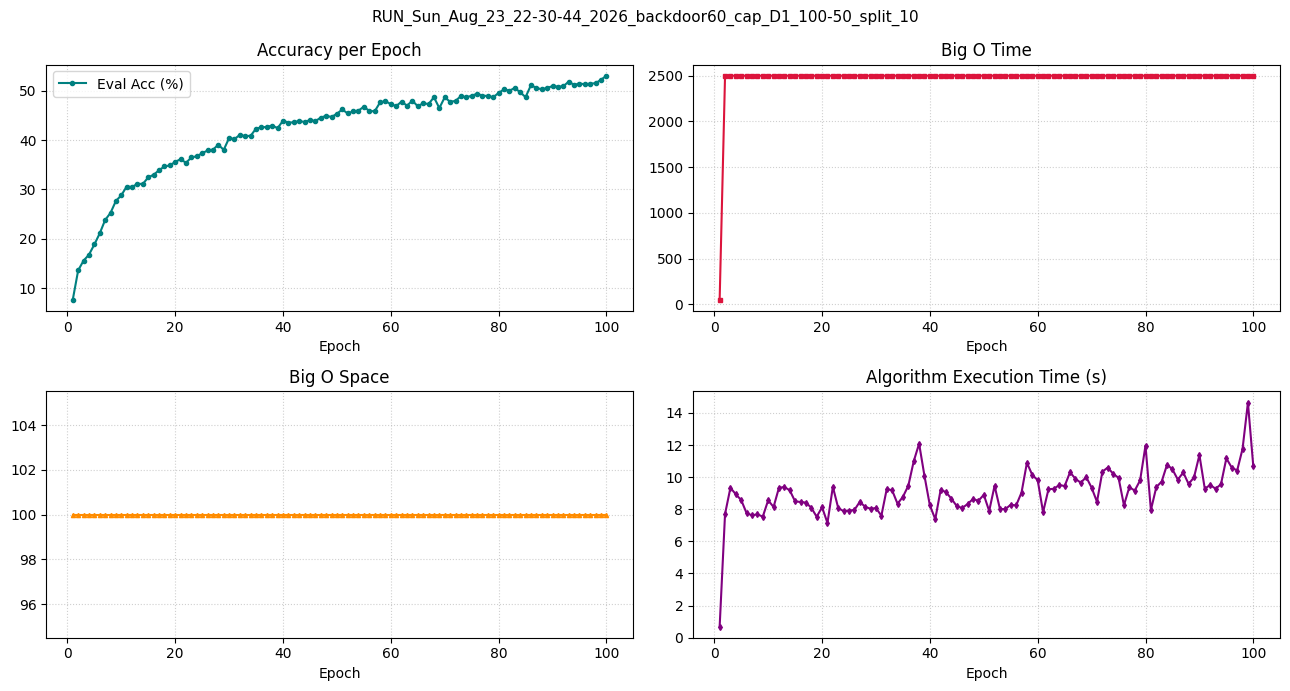

In [126]:
res1 = analyze_run(attack="backdoor60", protocol="fedattract", data_type="d1")
res2 = analyze_run(attack="backdoor60", protocol="cap", data_type="d1")

In [106]:
#############################################################

RUN: RUN_Tue_Aug_25_15-44-08_2026_subtle40_fedattract_D1_100-50_split_10
Configuration -> Attack: majoritybyz40 | Protocol: fedattract | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    32 (64.00%)
Malicious Clients: 18 (36.00%)
Total BigO Time: 11427
Final Acc: 51.11%


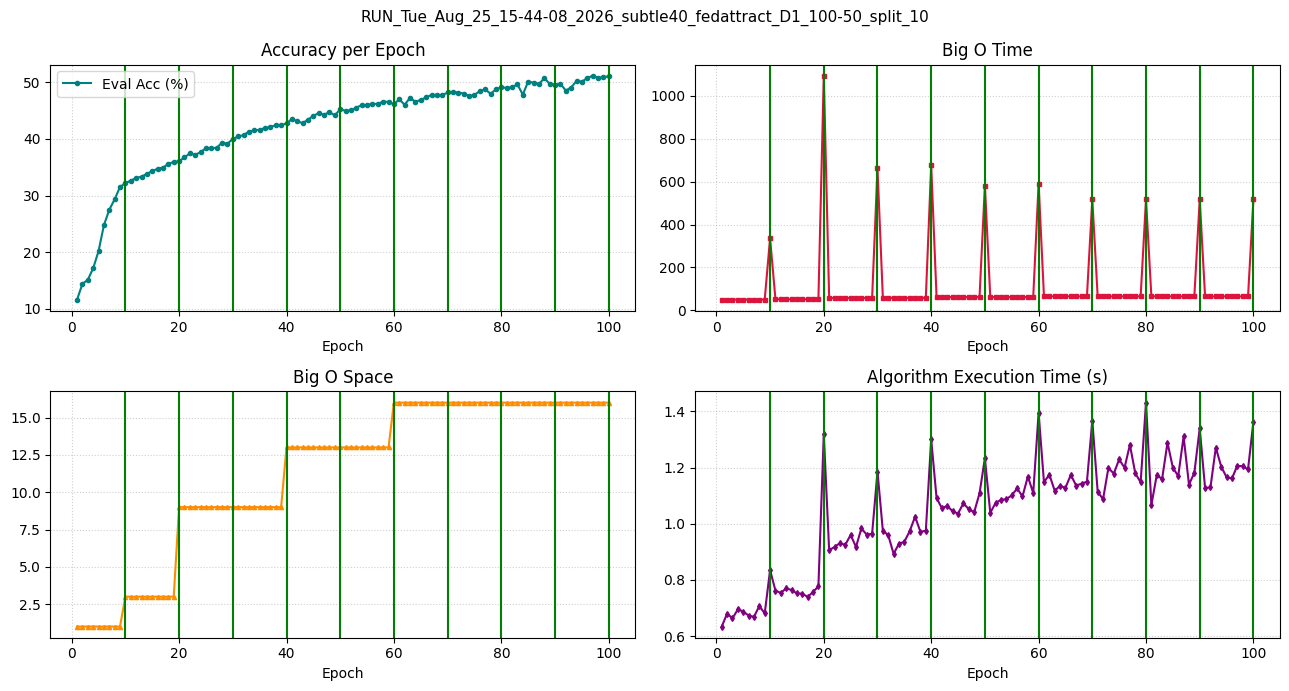

RUN: RUN_Tue_Aug_25_21-20-32_2026_subtle40_cap_D1_100-50_split_10
Configuration -> Attack: majoritybyz40 | Protocol: cap | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    32 (64.00%)
Malicious Clients: 18 (36.00%)
Total BigO Time: 125042
Final Acc: 53.15%


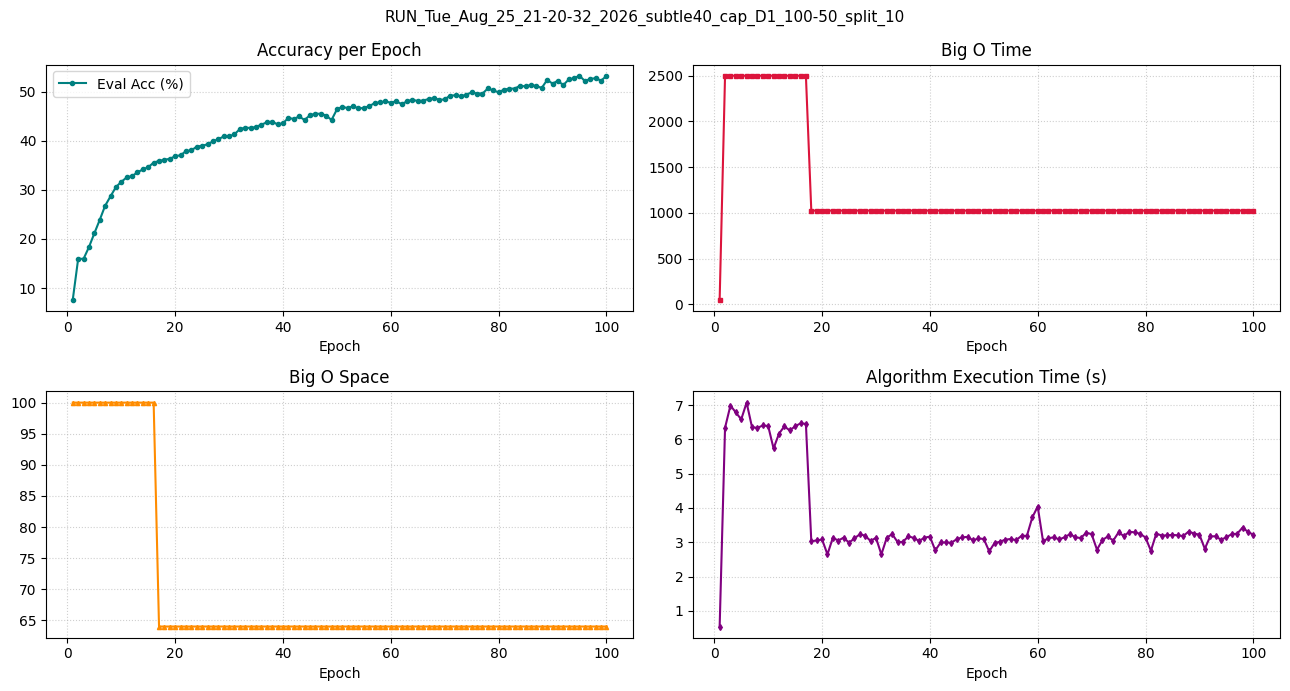

In [127]:
res1 = analyze_run(attack="majoritybyz40", protocol="fedattract", data_type="d1")
res2 = analyze_run(attack="majoritybyz40", protocol="cap", data_type="d1")

RUN: RUN_Wed_Aug_26_15-25-37_2026_labelswitch40_fedattract_D1_100-50_split_10
Configuration -> Attack: labelswitch40 | Protocol: fedattract | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    32 (64.00%)
Malicious Clients: 18 (36.00%)
Total BigO Time: 11378
Final Acc: 52.77%


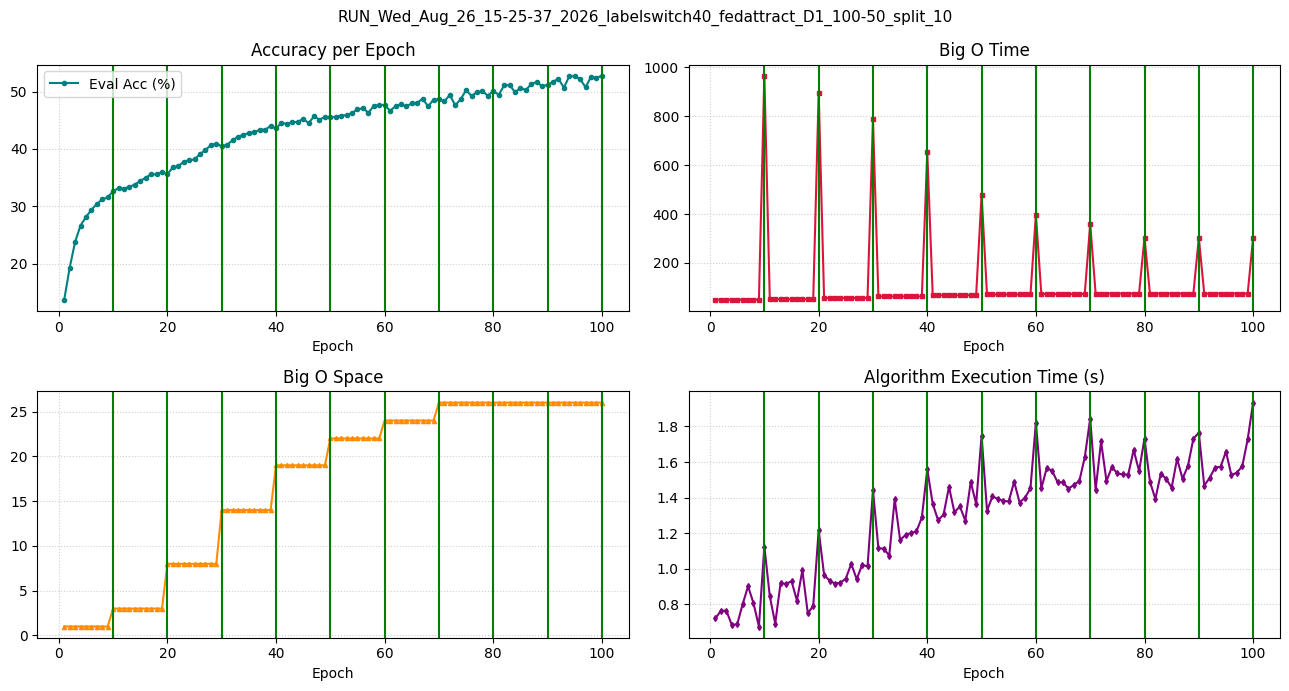

RUN: RUN_Wed_Aug_26_21-45-33_2026_labelswitch40_cap_D1_100-50_split_10
Configuration -> Attack: labelswitch40 | Protocol: cap | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    32 (64.00%)
Malicious Clients: 18 (36.00%)
Total BigO Time: 247550
Final Acc: 53.9%


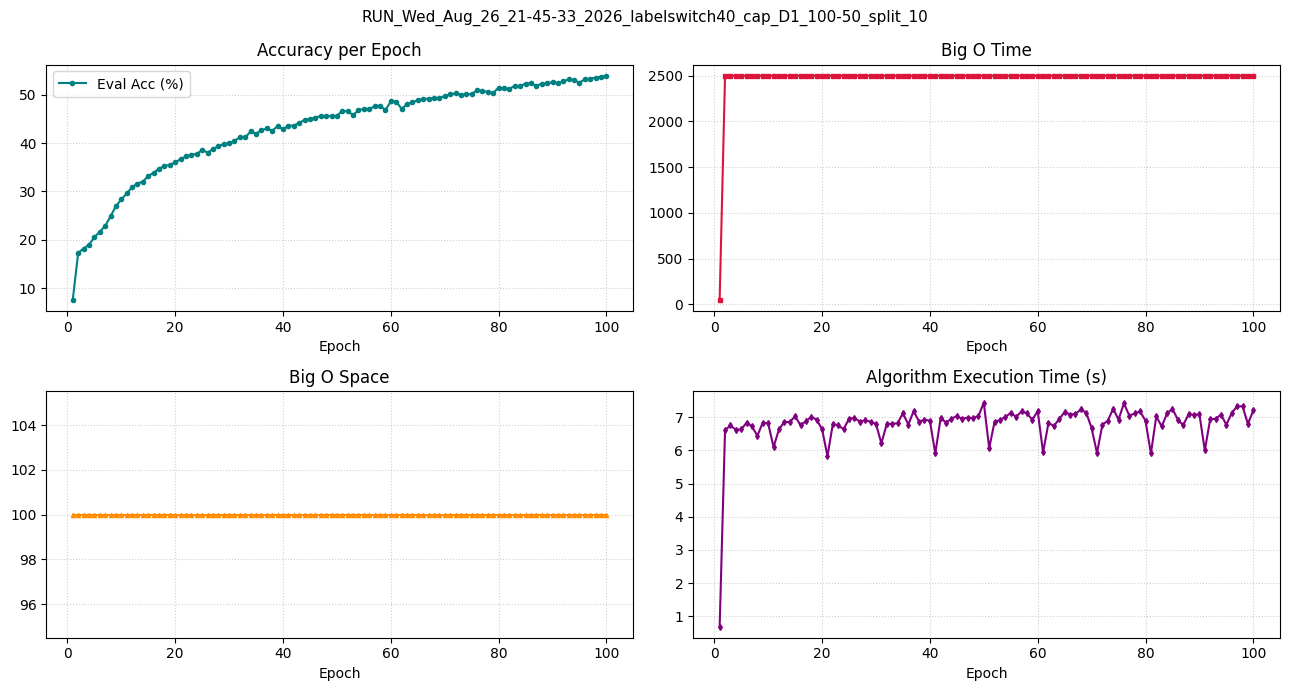

In [128]:
res1 = analyze_run(attack="labelswitch40", protocol="fedattract", data_type="d1")
res2 = analyze_run(attack="labelswitch40", protocol="cap", data_type="d1")

RUN: RUN_Wed_Aug_26_03-09-51_2026_backdoor40_fedattract_D1_100-50_split_10
Configuration -> Attack: backdoor40 | Protocol: fedattract | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    32 (64.00%)
Malicious Clients: 18 (36.00%)
Total BigO Time: 10989
Final Acc: 51.47%


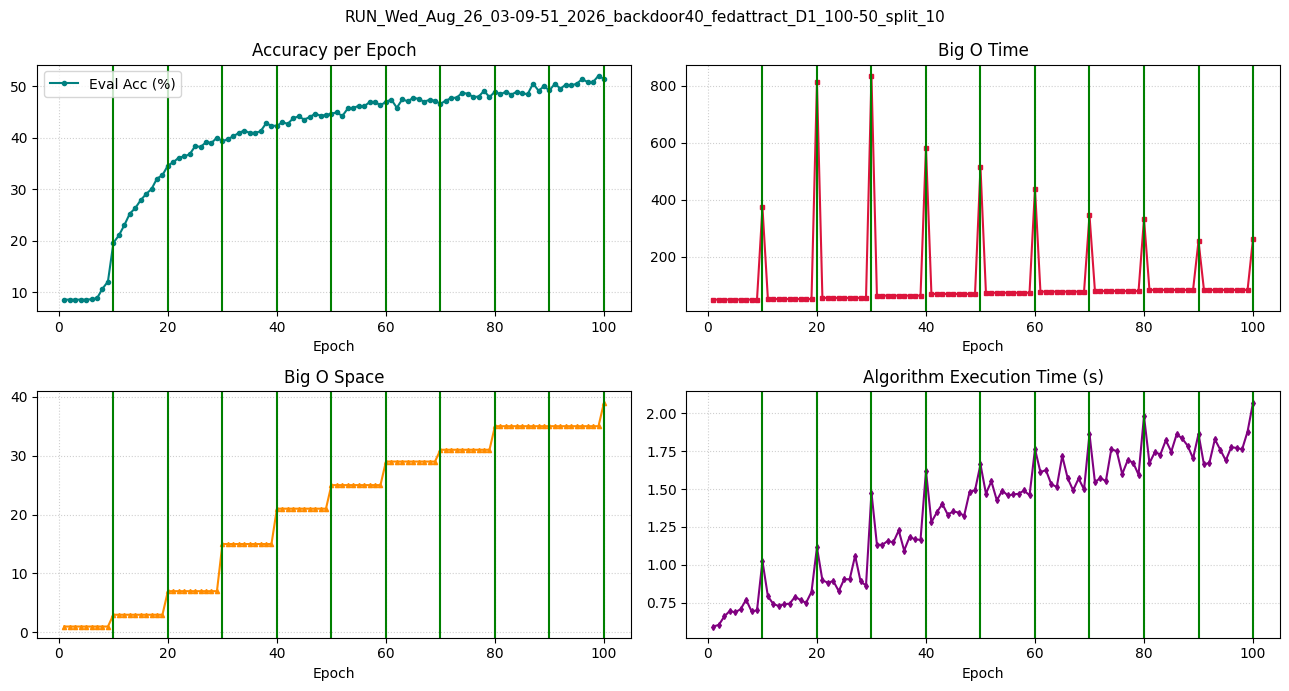

RUN: RUN_Wed_Aug_26_09-07-46_2026_backdoor40_cap_D1_100-50_split_10
Configuration -> Attack: backdoor40 | Protocol: cap | Data: d1
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    32 (64.00%)
Malicious Clients: 18 (36.00%)
Total BigO Time: 247550
Final Acc: 52.23%


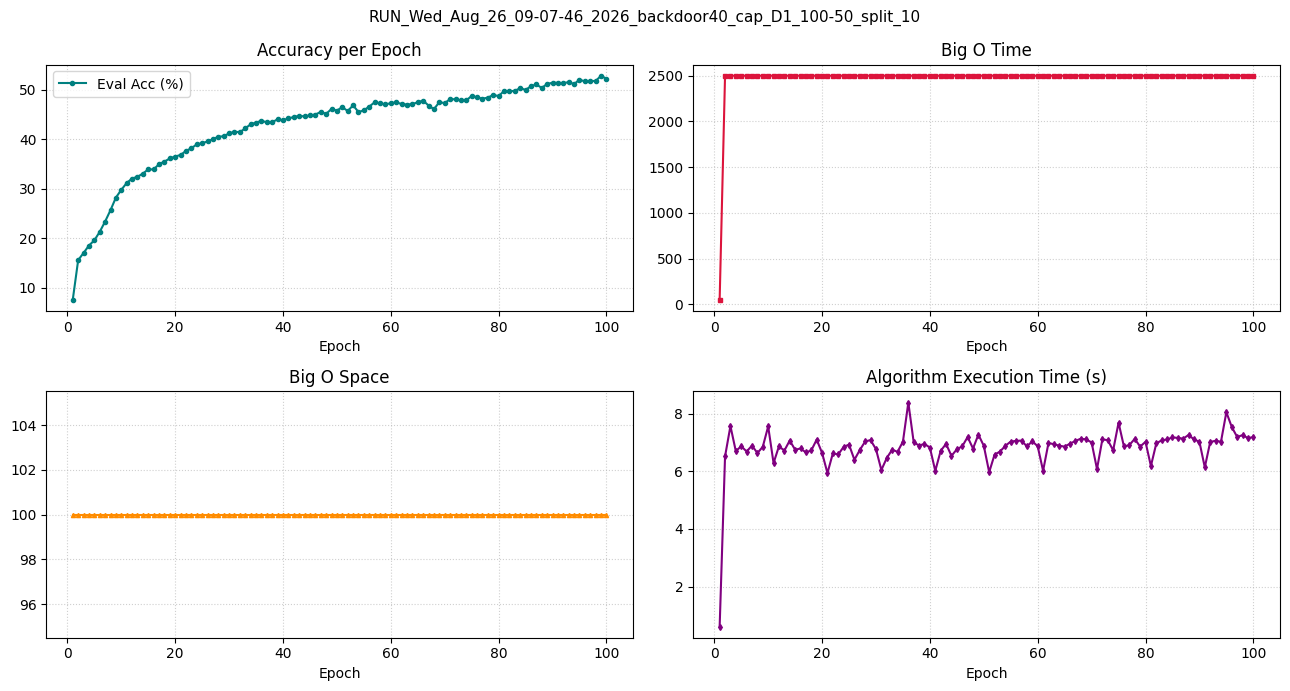

In [129]:
res1 = analyze_run(attack="backdoor40", protocol="fedattract", data_type="d1")
res2 = analyze_run(attack="backdoor40", protocol="cap", data_type="d1")

In [130]:
#################################################################################
#################################################################################
#################################################################################
#################################################################################

Found 2 matching runs. Displaying run index 0:
RUN: RUN_Tue_Sep__1_08-48-00_2026_late_subtle60_fedattract_pathalogical
Configuration -> Attack: majoritybyz60 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 9194
Final Acc: 49.61%


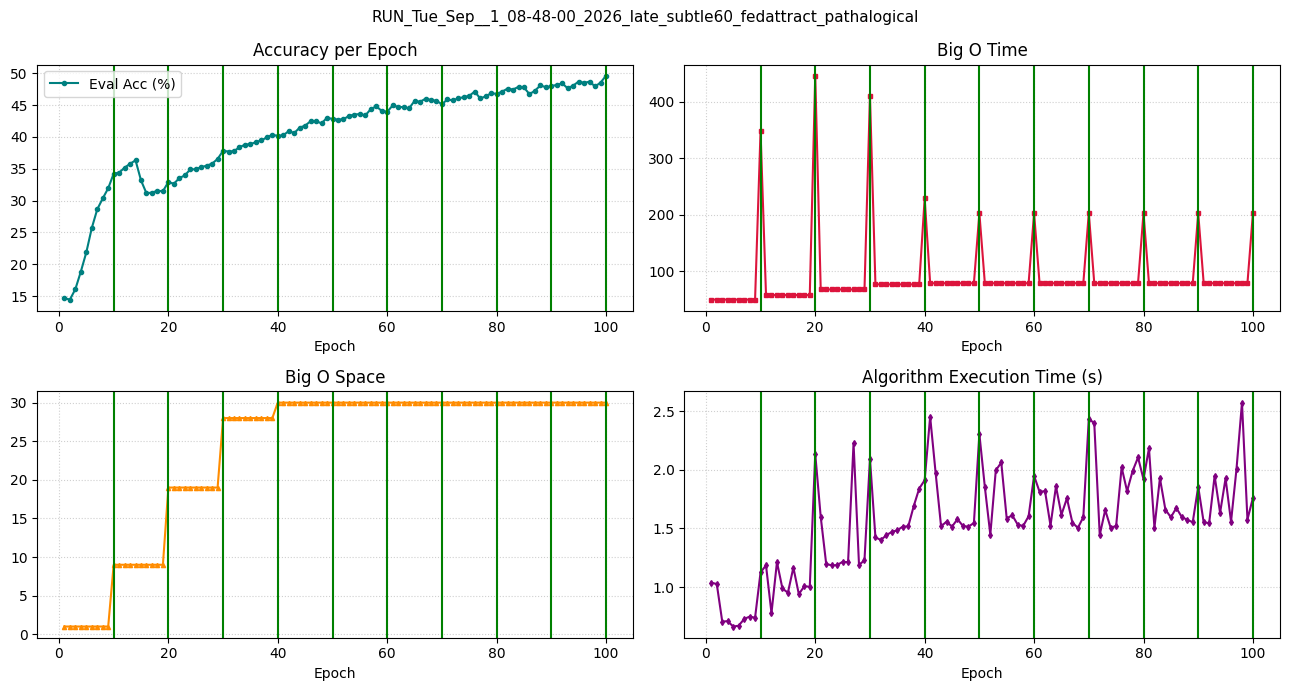

Found 2 matching runs. Displaying run index 0:
RUN: RUN_Tue_Sep__1_21-47-06_2026_late_subtle60_cap_pathalogical
Configuration -> Attack: majoritybyz60 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 129047
Final Acc: 10.71%


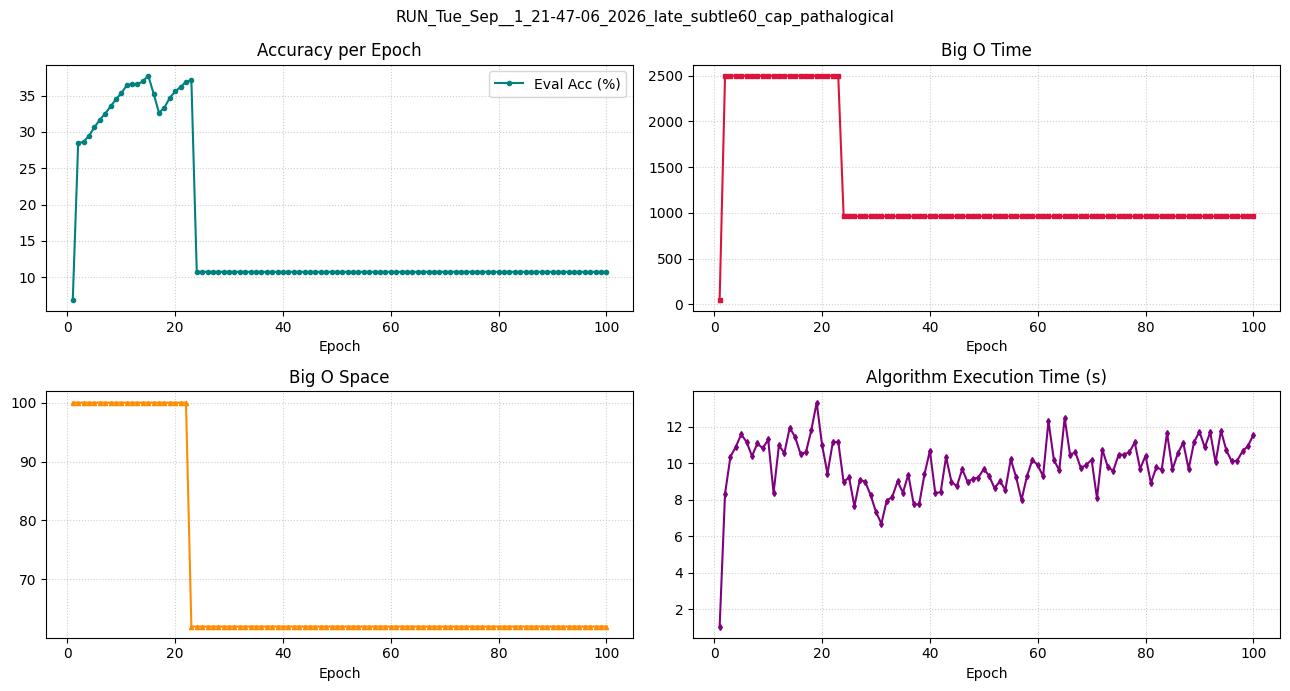

In [131]:
res1 = analyze_run(attack="majoritybyz60", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="majoritybyz60", protocol="cap", data_type="pathalogical")

Found 2 matching runs. Displaying run index 0:
RUN: RUN_Sat_Aug_29_16-43-38_2026_late_alie60_fedattract_pathalogical
Configuration -> Attack: alie60 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 9455
Final Acc: 56.49%


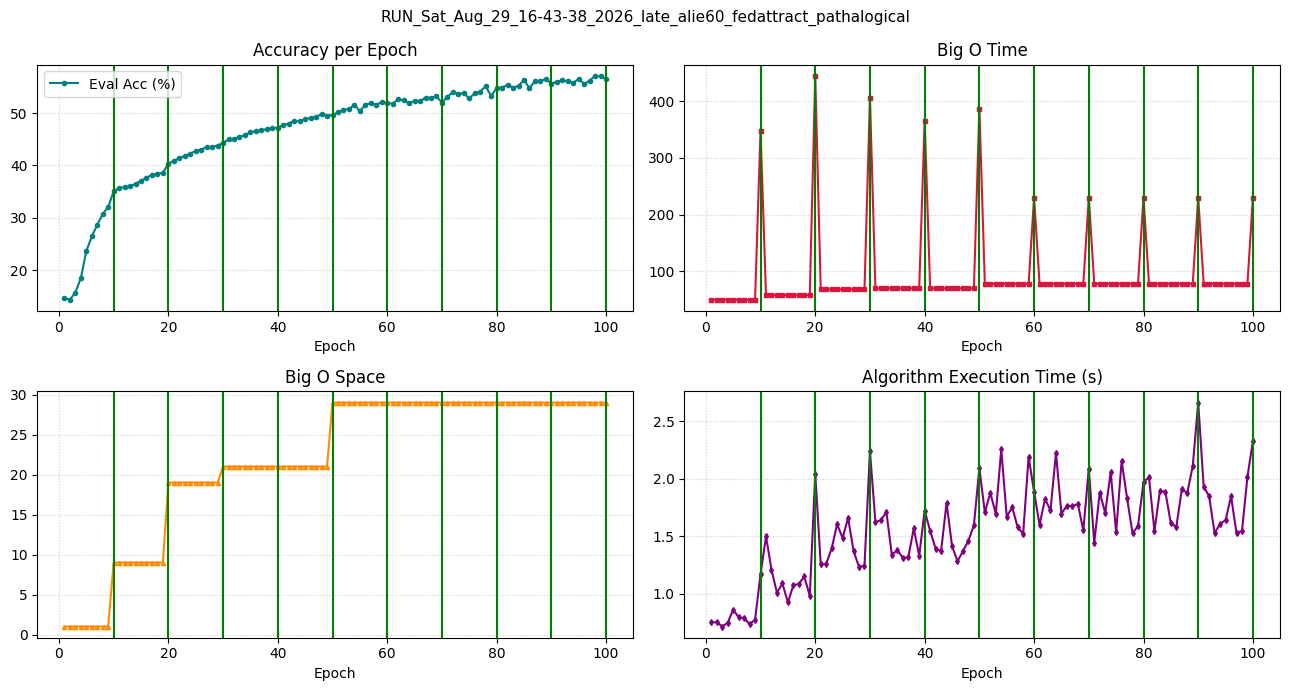

Found 2 matching runs. Displaying run index 0:
RUN: RUN_Thu_Aug_27_13-27-34_2026_alie60_cap_pathalogical
Configuration -> Attack: alie60 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 247550
Final Acc: 58.47%


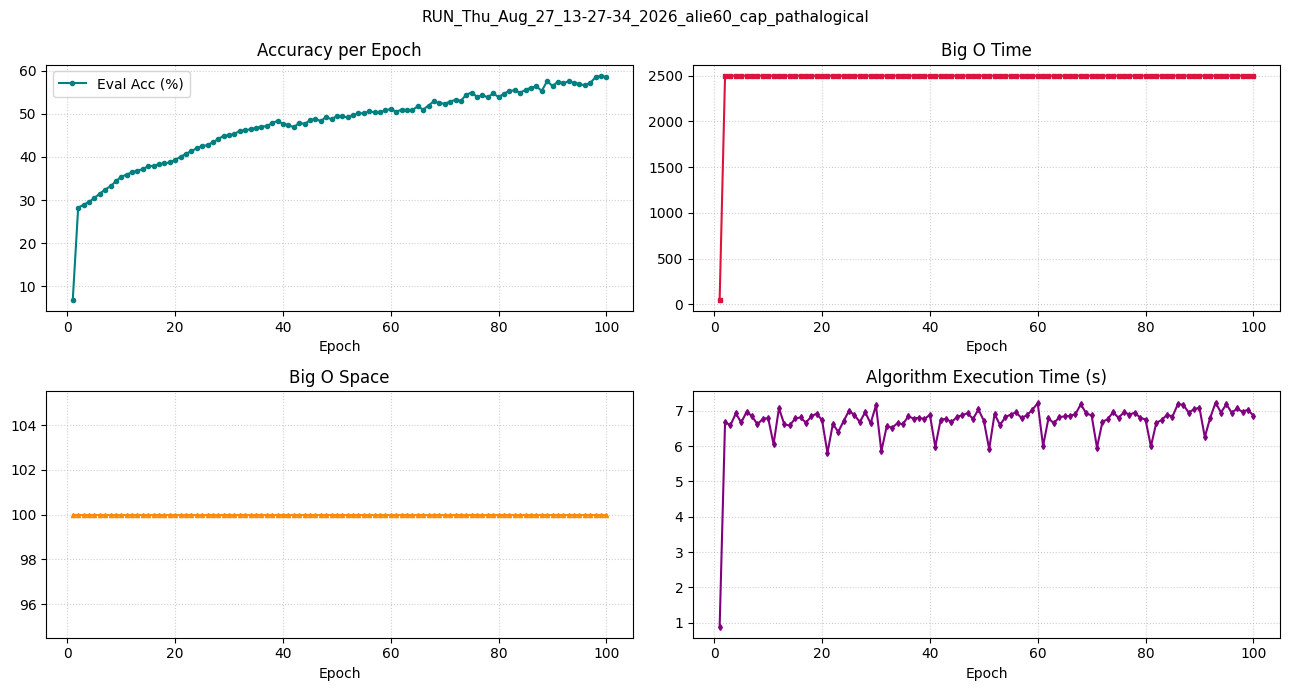

In [134]:
res1 = analyze_run(attack="alie60", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="alie60", protocol="cap", data_type="pathalogical")

Found 2 matching runs. Displaying run index 0:
RUN: RUN_Mon_Aug_31_02-06-36_2026_late_lblswitch60_fedattract_pathalogical
Configuration -> Attack: labelswitch60 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 9530
Final Acc: 55.63%


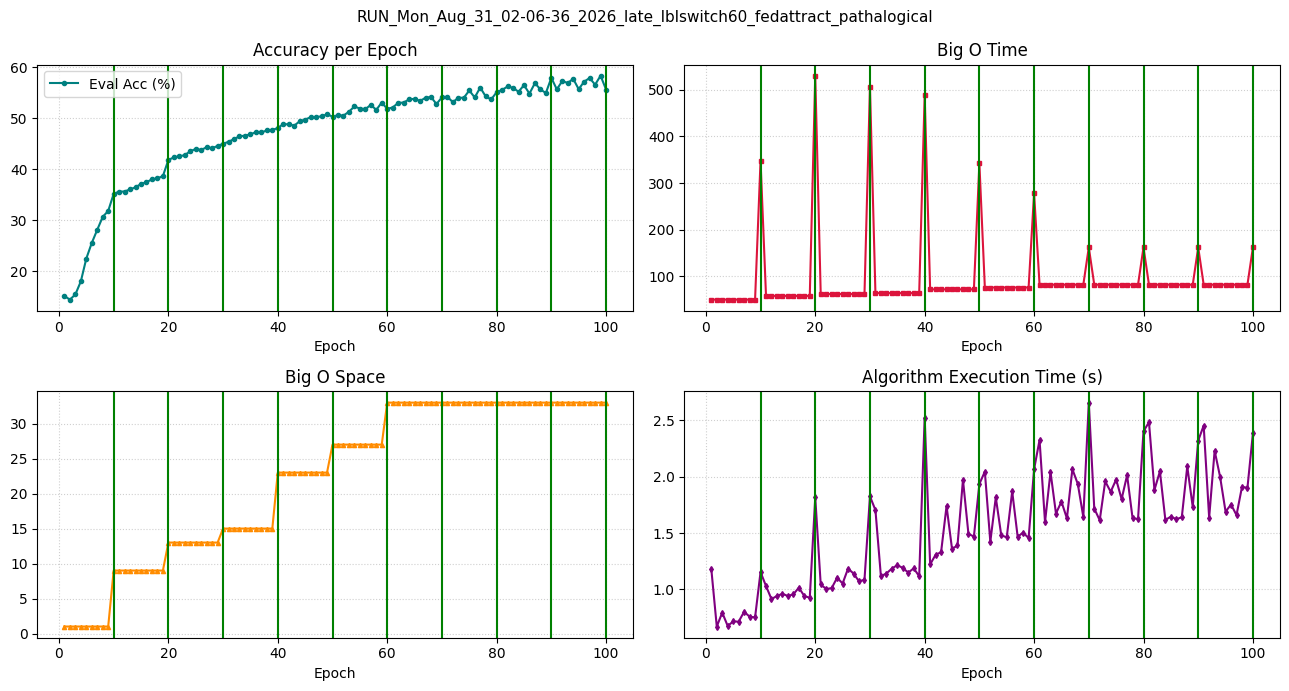

Found 2 matching runs. Displaying run index 0:
RUN: RUN_Thu_Aug_20_15-36-43_2026_labelswitch60_cap_pathalogical_100-50_split_10
Configuration -> Attack: labelswitch60 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 247550
Final Acc: 58.24%


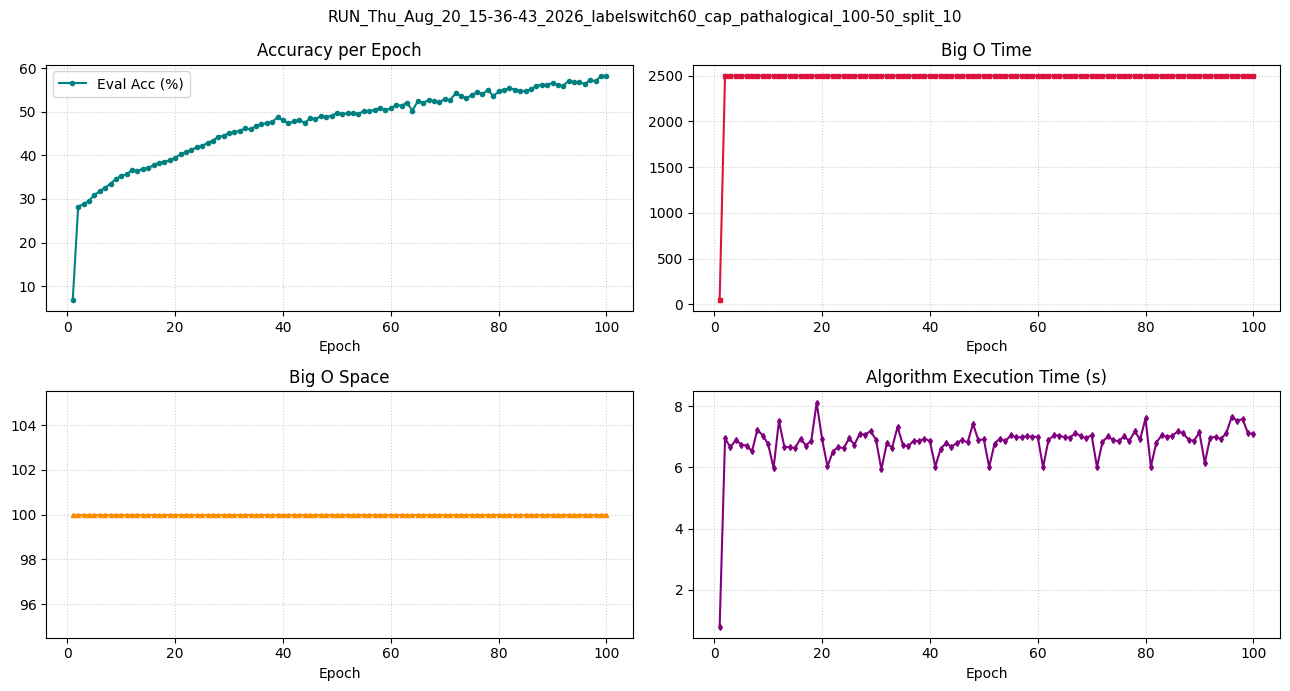

In [135]:
res1 = analyze_run(attack="labelswitch60", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="labelswitch60", protocol="cap", data_type="pathalogical")

RUN: RUN_Wed_Aug_19_20-28-42_2026_backdoor60_fedattract_pathalogical_100-50_split_10
Configuration -> Attack: backdoor60 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 9937
Final Acc: 56.81%


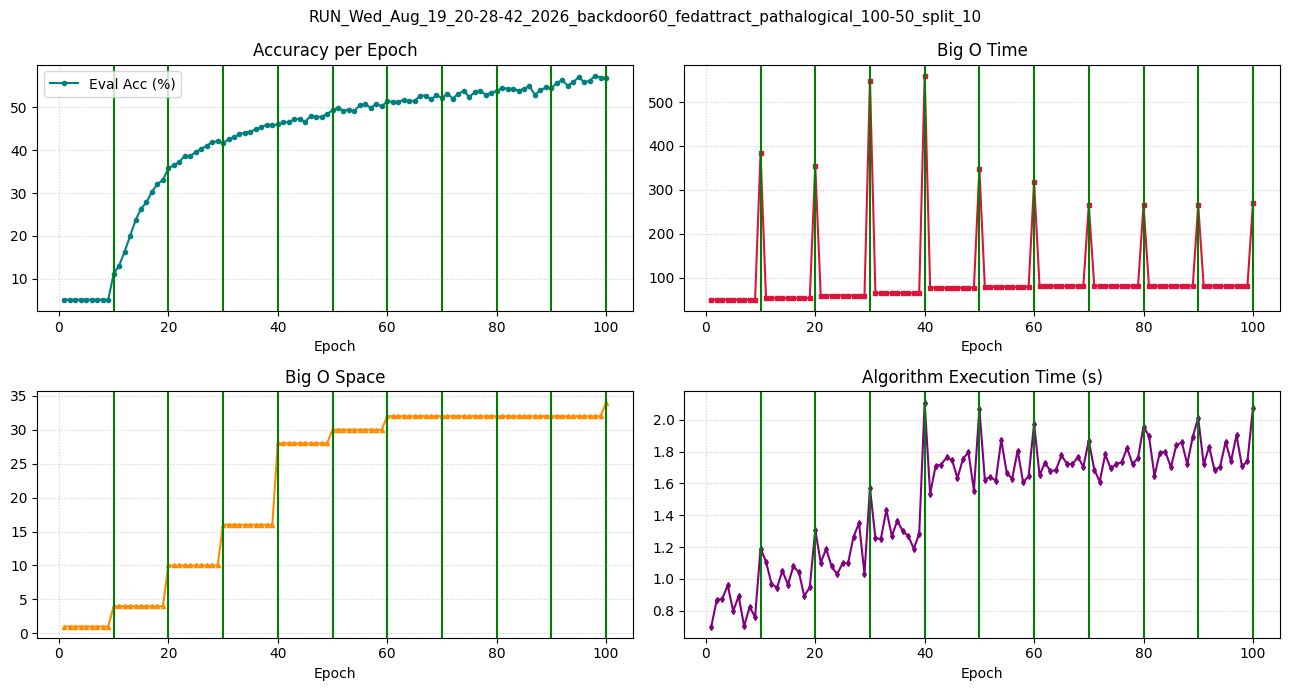

RUN: RUN_Thu_Aug_20_02-40-01_2026_backdoor60_cap_pathalogical_100-50_split_10
Configuration -> Attack: backdoor60 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 247550
Final Acc: 55.39%


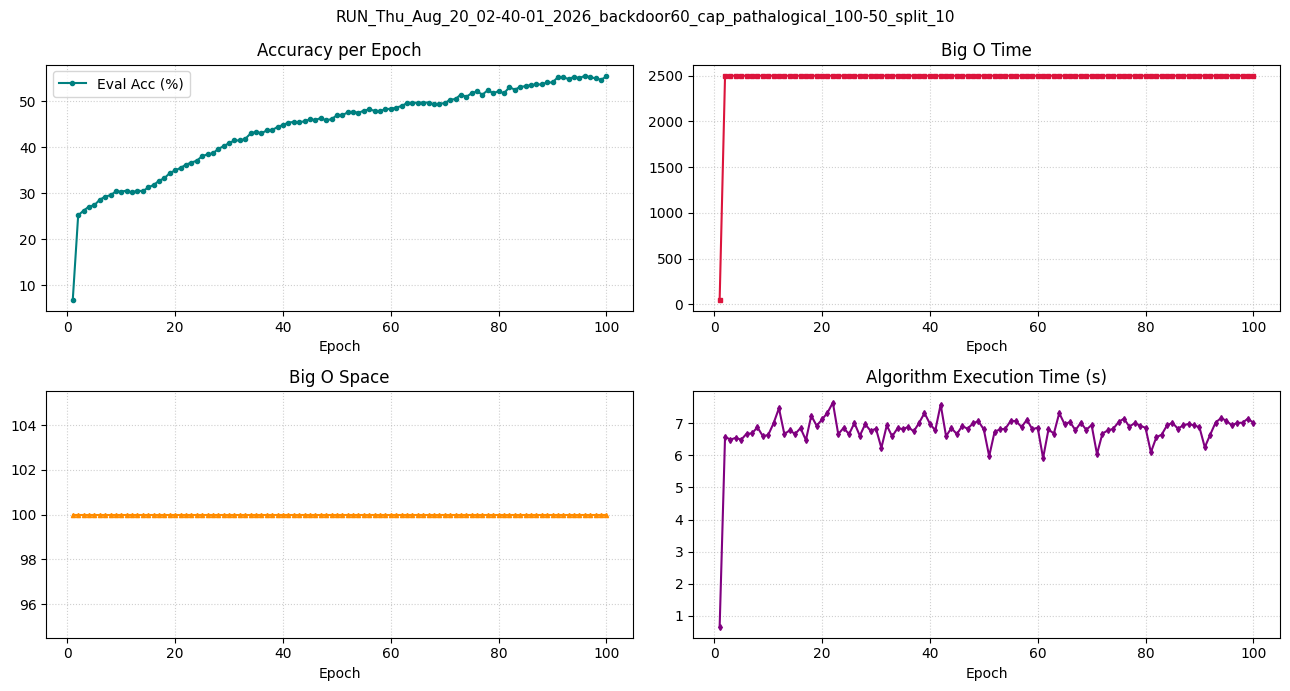

In [167]:
res1 = analyze_run(attack="backdoor60", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="backdoor60", protocol="cap", data_type="pathalogical")

In [139]:
#############################################################

RUN: RUN_Thu_Aug_20_22-21-42_2026_subtle40_fedattract_pathalogical_100-50_split_10
Configuration -> Attack: majoritybyz40 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    28 (56.00%)
Malicious Clients: 22 (44.00%)
Total BigO Time: 11565
Final Acc: 58.01%


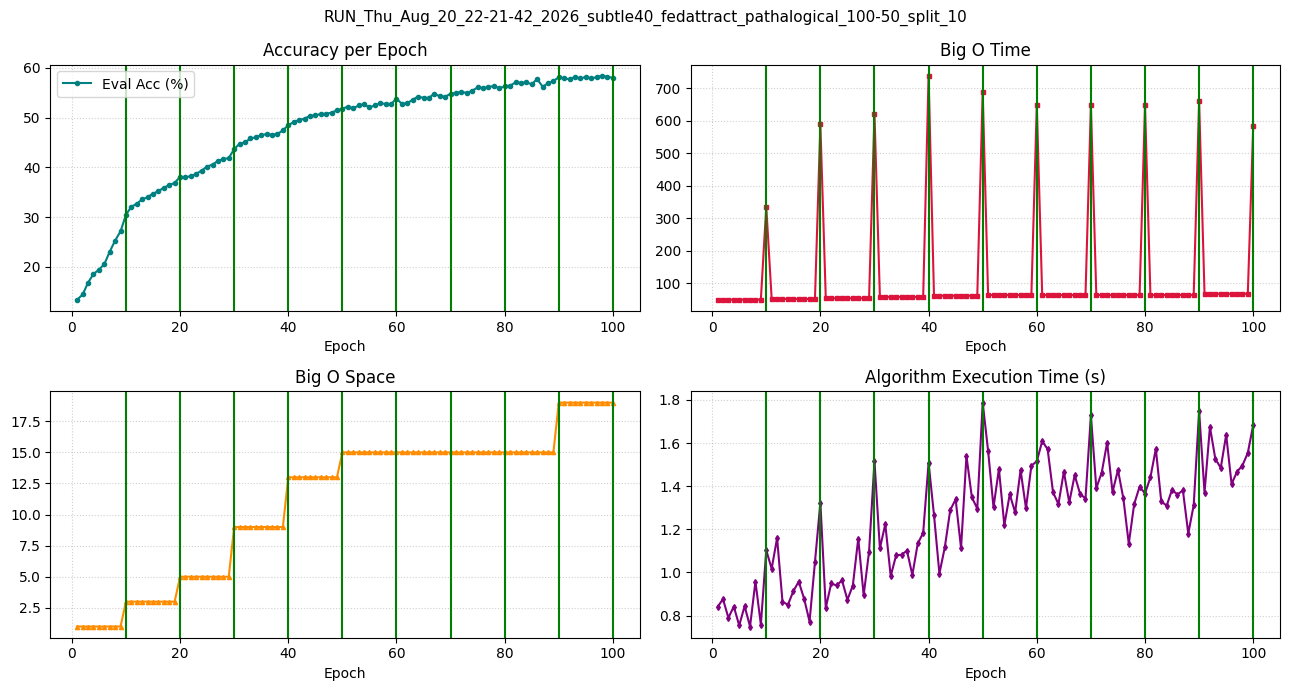

RUN: RUN_Fri_Aug_21_05-19-56_2026_subtle40_cap_pathalogical_100-50_split_10
Configuration -> Attack: majoritybyz40 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    28 (56.00%)
Malicious Clients: 22 (44.00%)
Total BigO Time: 89678
Final Acc: 59.23%


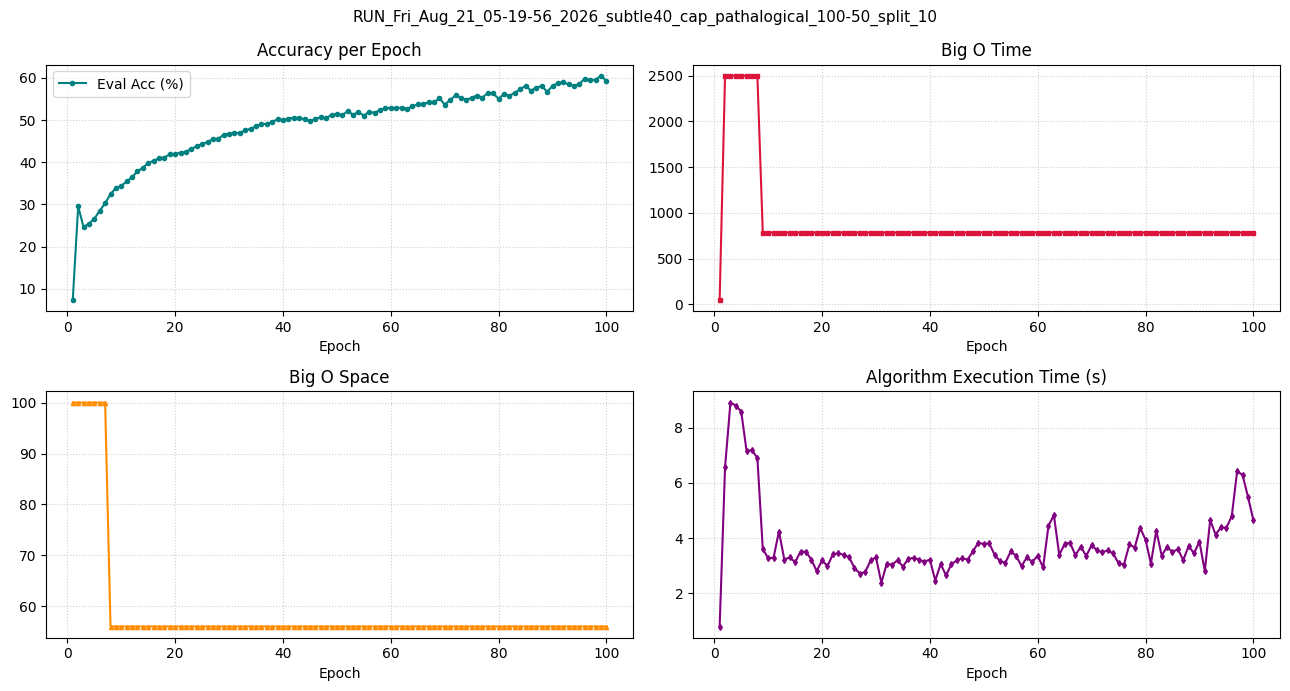

In [142]:
res1 = analyze_run(attack="majoritybyz40", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="majoritybyz40", protocol="cap", data_type="pathalogical")

RUN: RUN_Sat_Aug_22_04-13-01_2026_labelswitch40_fedattract_pathalogical_100-50_split_10
Configuration -> Attack: labelswitch40 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    28 (56.00%)
Malicious Clients: 22 (44.00%)
Total BigO Time: 9519
Final Acc: 59.22%


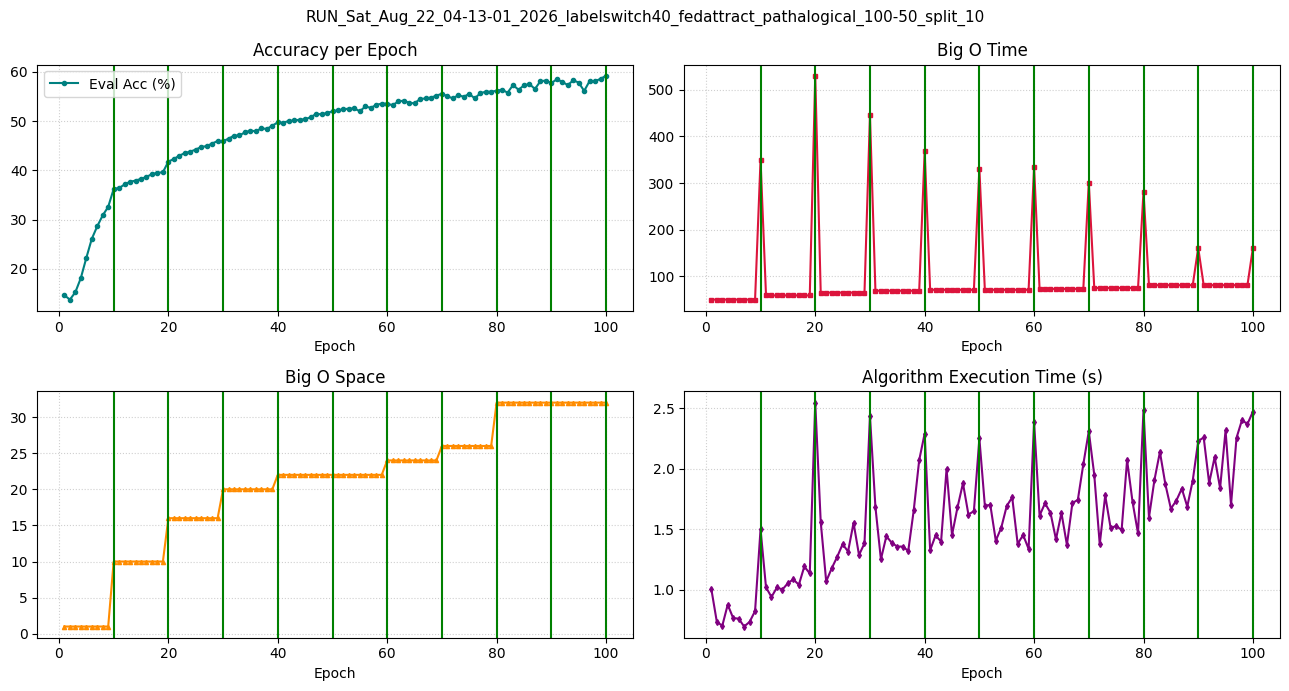

RUN: RUN_Sat_Aug_22_12-24-08_2026_labelswitch40_cap_pathalogical_100-50_split_10
Configuration -> Attack: labelswitch40 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    28 (56.00%)
Malicious Clients: 22 (44.00%)
Total BigO Time: 247550
Final Acc: 58.54%


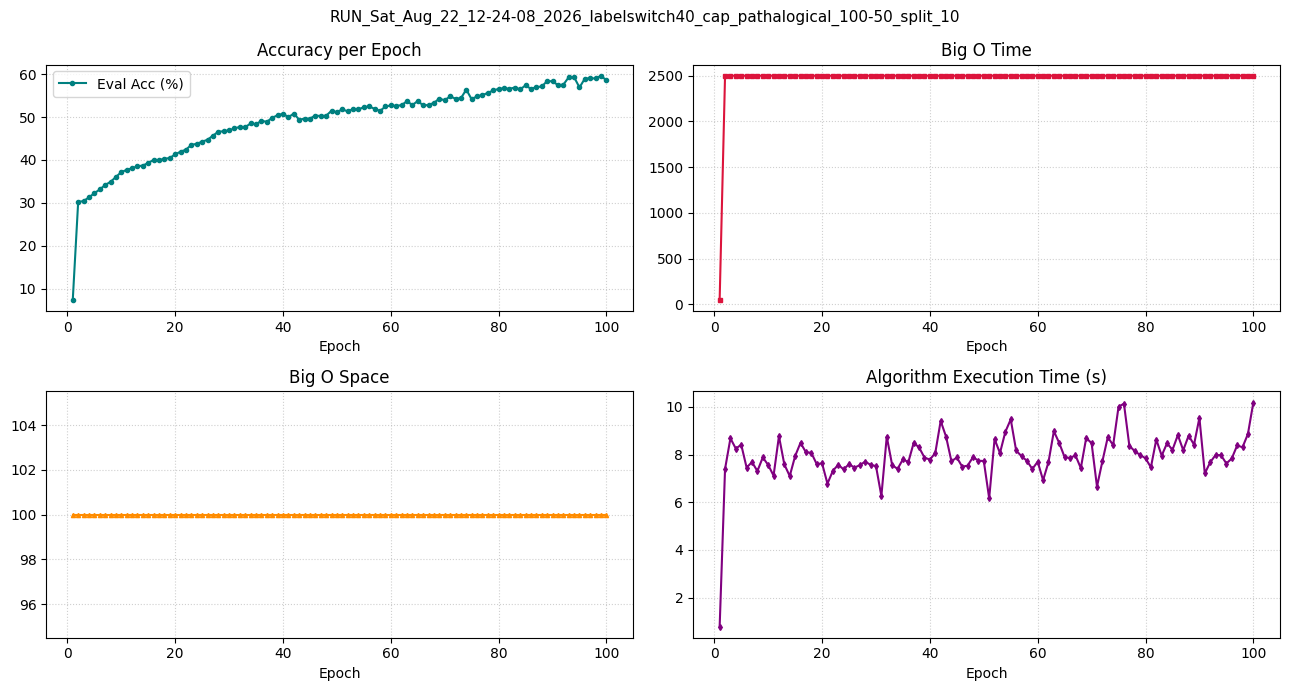

In [143]:
res1 = analyze_run(attack="labelswitch40", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="labelswitch40", protocol="cap", data_type="pathalogical")

RUN: RUN_Fri_Aug_21_12-33-06_2026_backdoor40_fedattract_pathalogical_100-50_split_10
Configuration -> Attack: backdoor40 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    28 (56.00%)
Malicious Clients: 22 (44.00%)
Total BigO Time: 10250
Final Acc: 58.16%


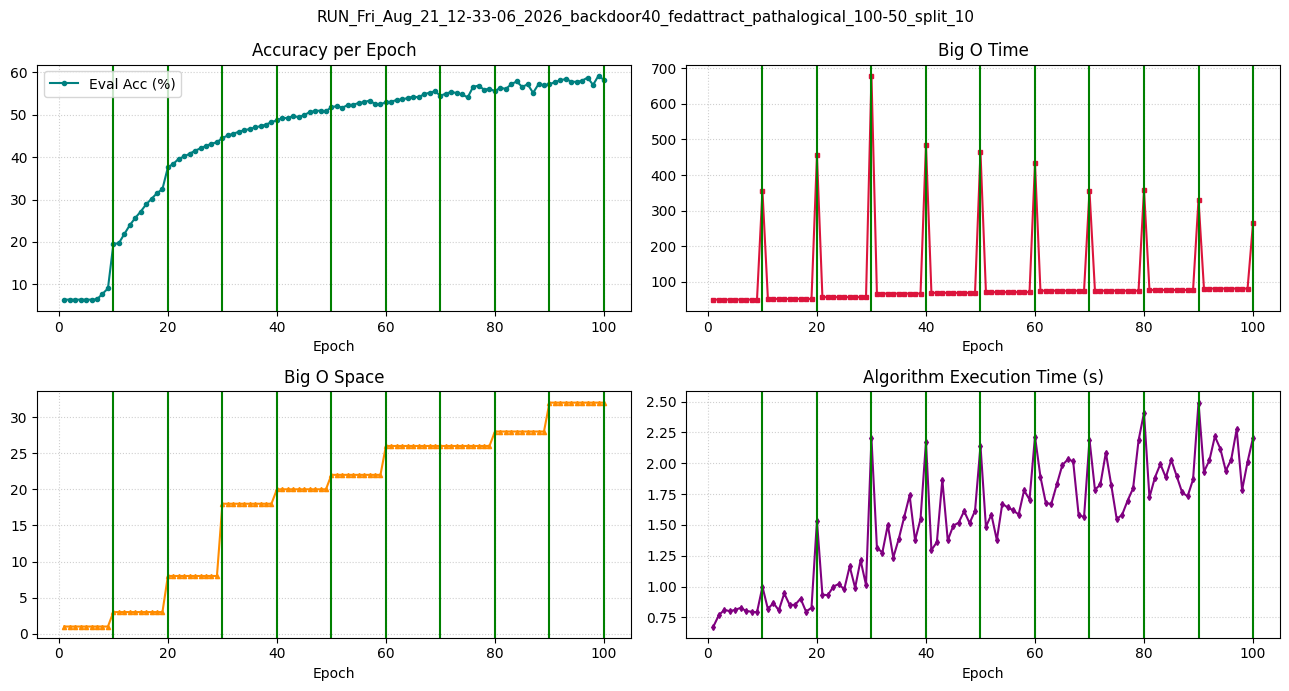

RUN: RUN_Fri_Aug_21_20-09-48_2026_backdoor40_cap_pathalogical_100-50_split_10
Configuration -> Attack: backdoor40 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    28 (56.00%)
Malicious Clients: 22 (44.00%)
Total BigO Time: 247550
Final Acc: 57.61%


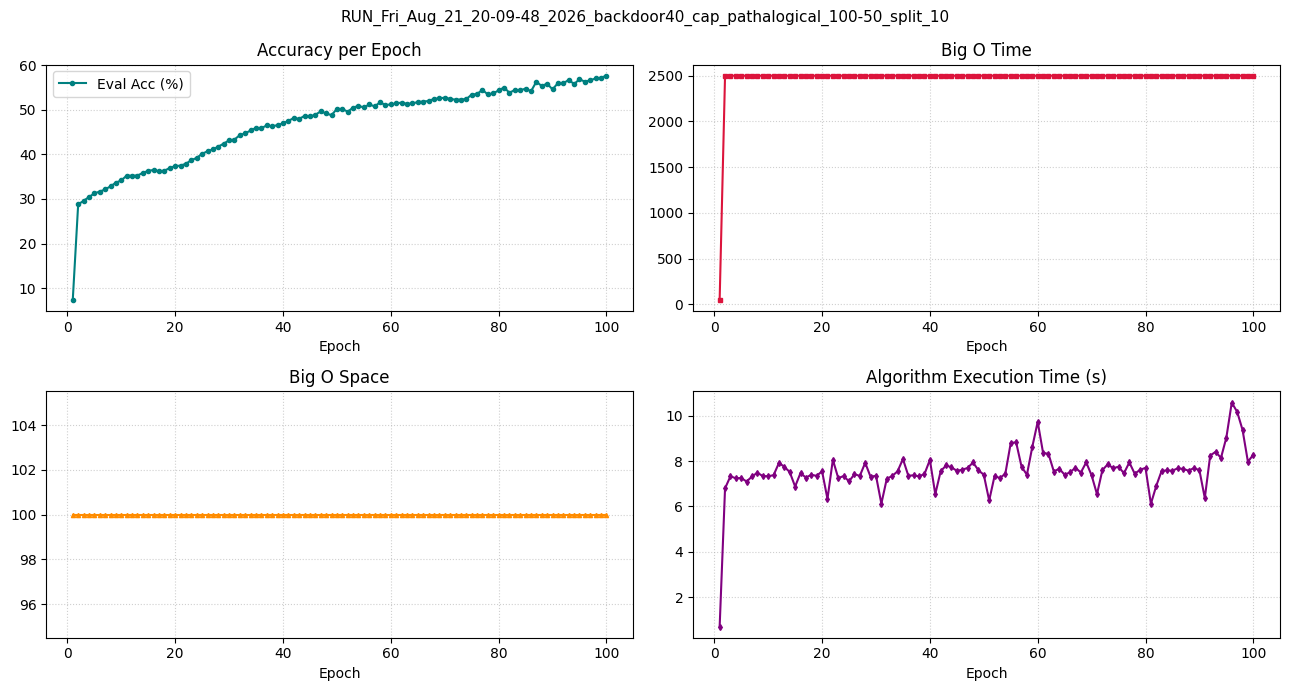

In [144]:
res1 = analyze_run(attack="backdoor40", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="backdoor40", protocol="cap", data_type="pathalogical")

In [160]:
############################################
# LATE ATTACKS
############################################

RUN: RUN_Tue_Sep__1_08-48-00_2026_late_subtle60_fedattract_pathalogical
Configuration -> Attack: late_majoritybyz60 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 9194
Final Acc: 49.61%


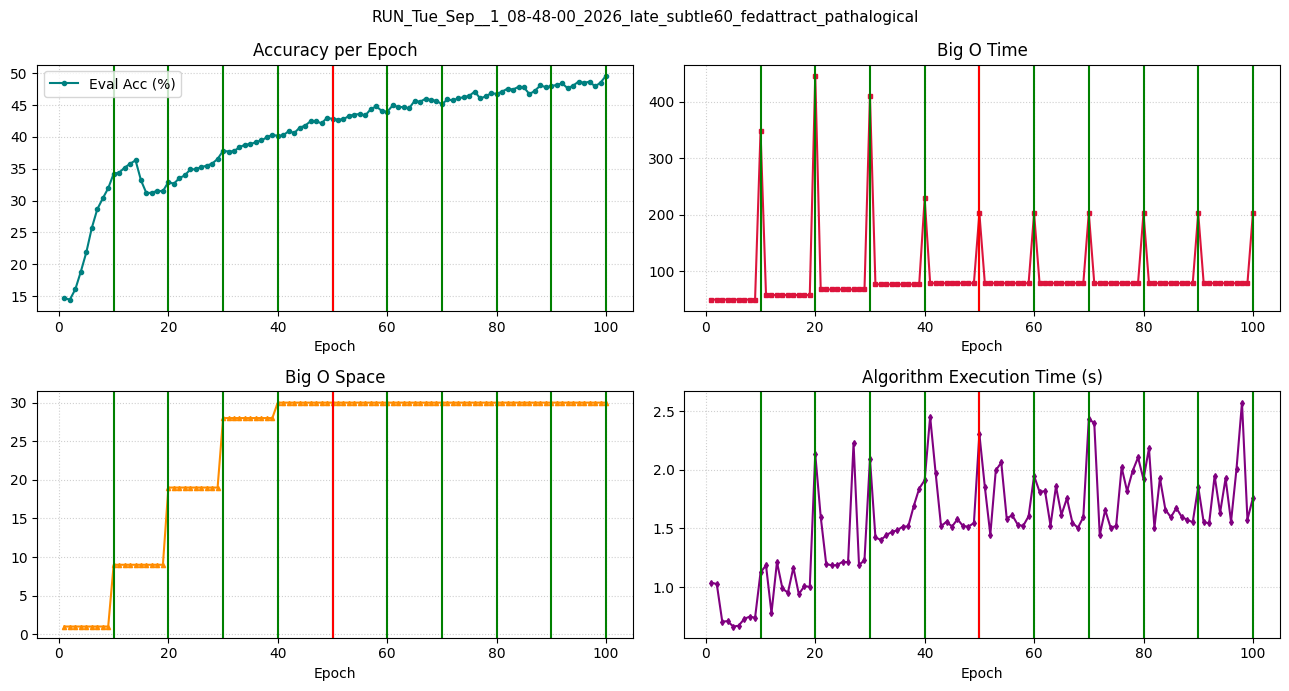

RUN: RUN_Tue_Sep__1_21-47-06_2026_late_subtle60_cap_pathalogical
Configuration -> Attack: late_majoritybyz60 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 129047
Final Acc: 10.71%


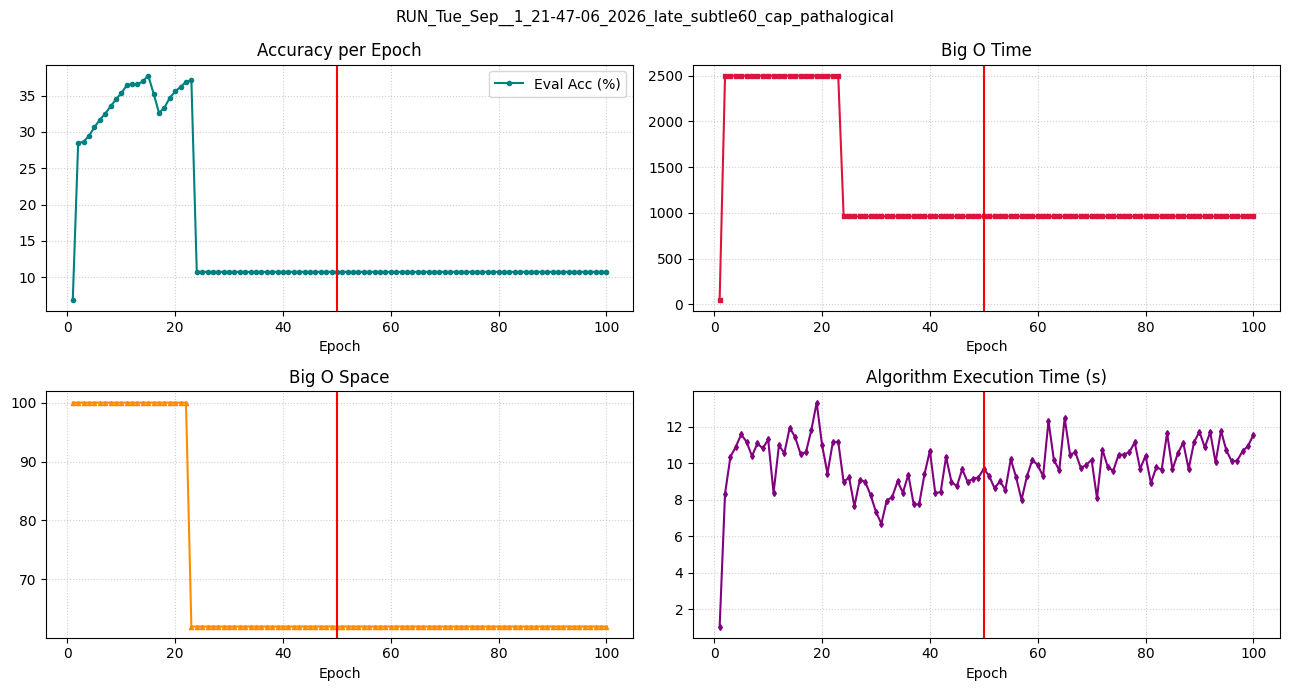

In [164]:
res1 = analyze_run(attack="late_majoritybyz60", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="late_majoritybyz60", protocol="cap", data_type="pathalogical")

RUN: RUN_Sat_Aug_29_16-43-38_2026_late_alie60_fedattract_pathalogical
Configuration -> Attack: late_alie60 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 9455
Final Acc: 56.49%


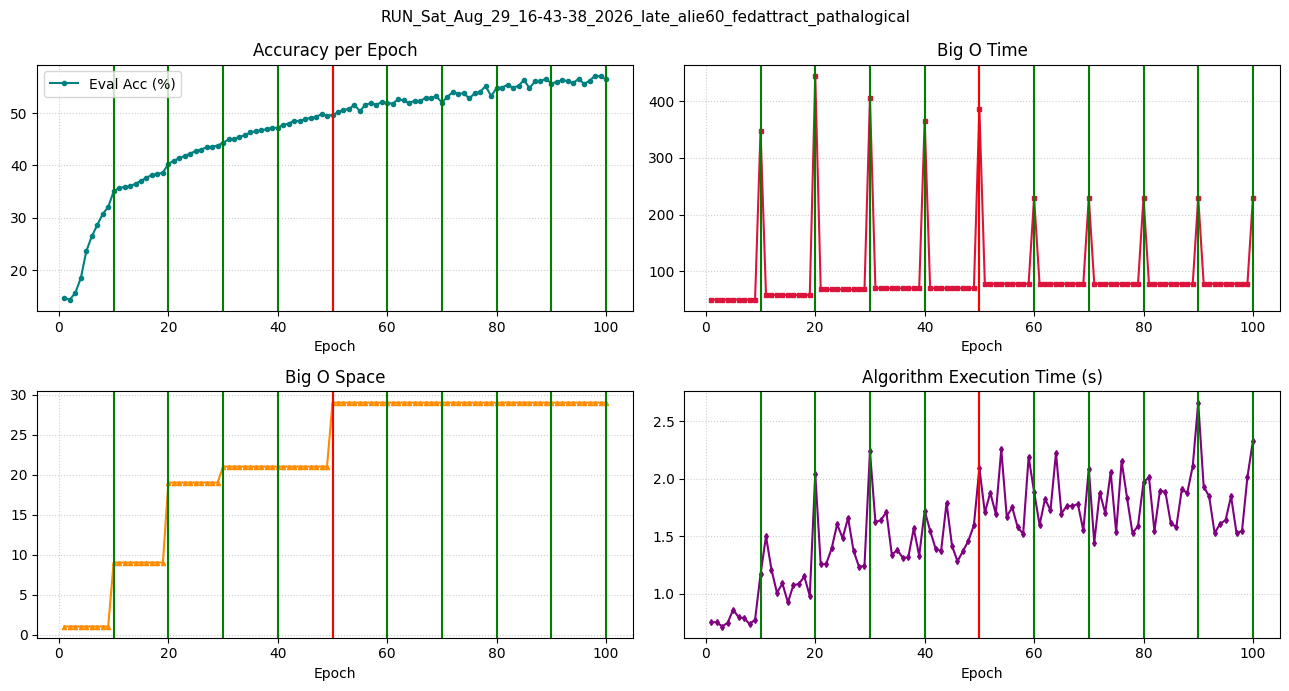

RUN: RUN_Sun_Aug_30_00-30-16_2026_late_alie60_cap_pathalogical
Configuration -> Attack: late_alie60 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 247550
Final Acc: 58.8%


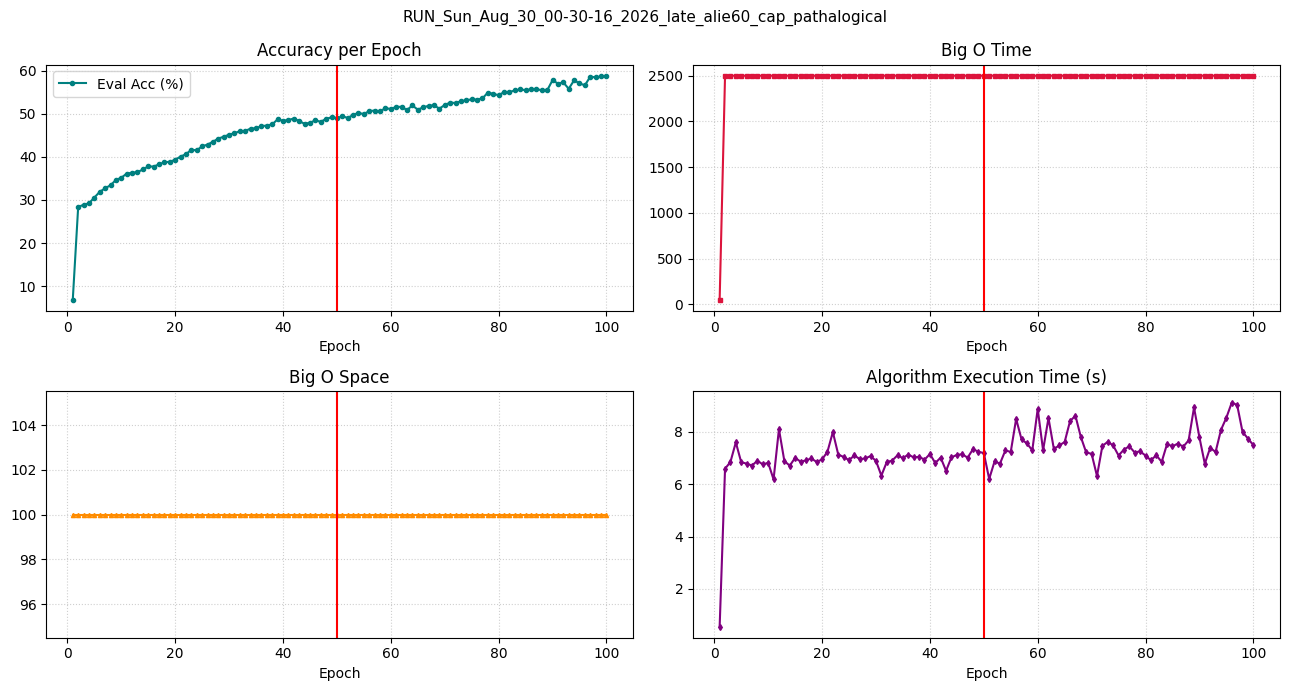

In [165]:
res1 = analyze_run(attack="late_alie60", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="late_alie60", protocol="cap", data_type="pathalogical")

RUN: RUN_Sun_Aug_30_08-41-22_2026_late_backdoor60_fedattract_pathalogical
Configuration -> Attack: late_backdoor60 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 9423
Final Acc: 54.44%


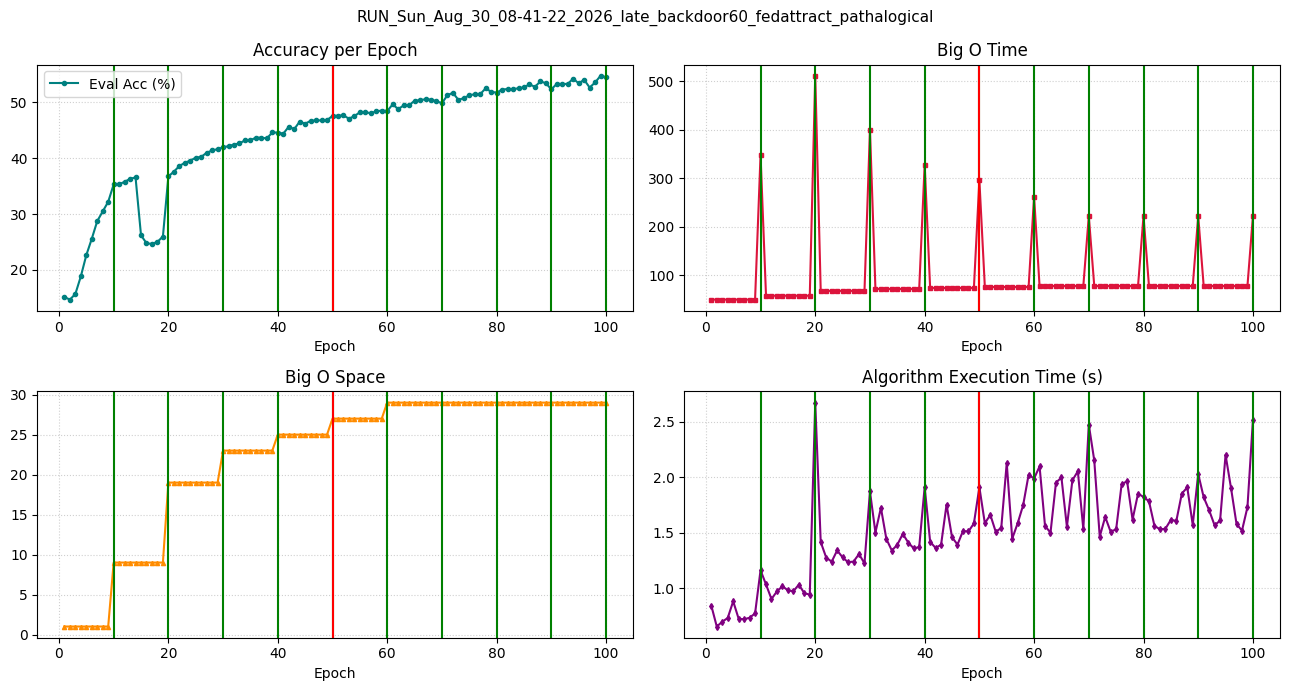

RUN: RUN_Sun_Aug_30_17-33-54_2026_late_backdoor60_cap_pathalogical
Configuration -> Attack: late_backdoor60 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 247550
Final Acc: 56.89%


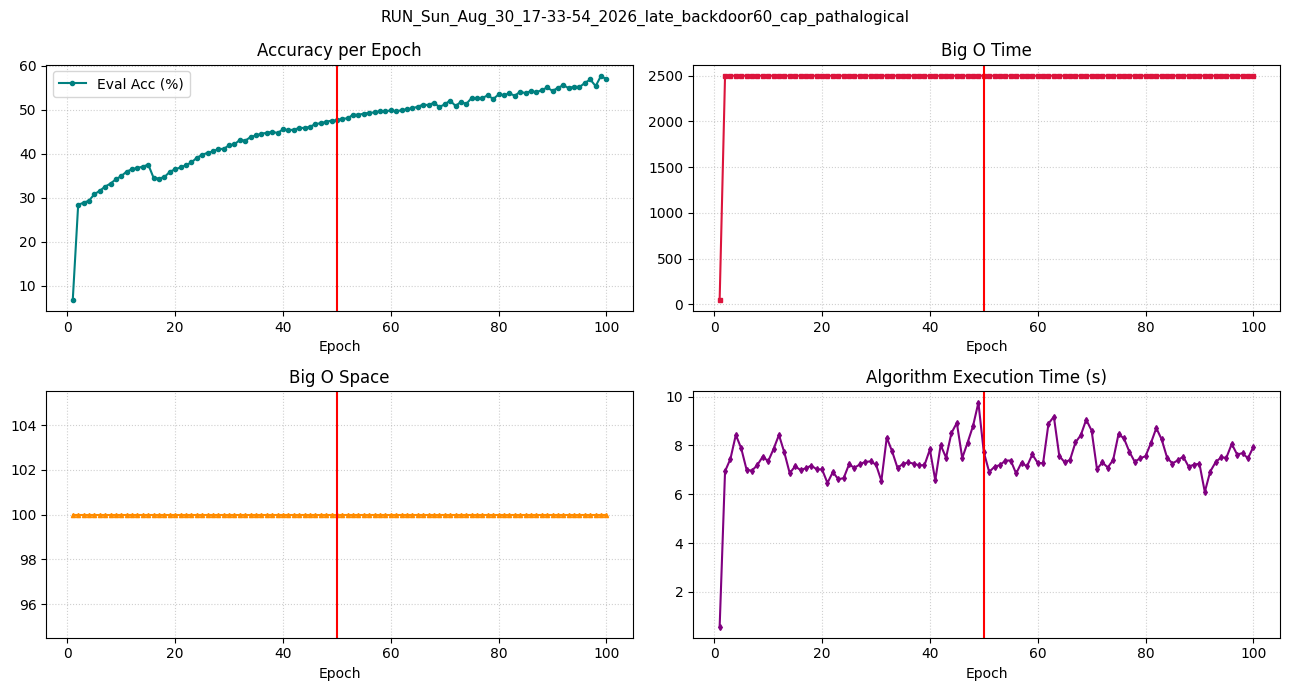

In [166]:
res1 = analyze_run(attack="late_backdoor60", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="late_backdoor60", protocol="cap", data_type="pathalogical")

RUN: RUN_Mon_Aug_31_02-06-36_2026_late_lblswitch60_fedattract_pathalogical
Configuration -> Attack: late_labelswitch60 | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 9530
Final Acc: 55.63%


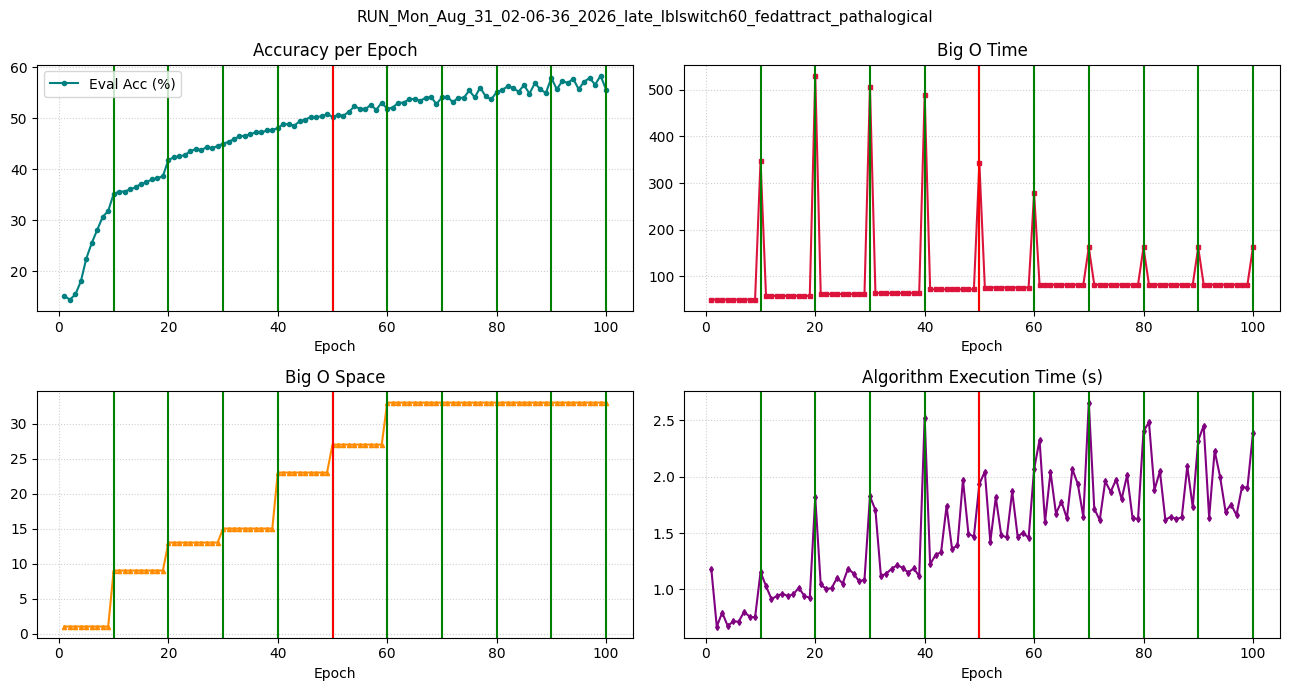

RUN: RUN_Mon_Aug_31_22-48-12_2026_late_lblswitch60_cap_pathalogical
Configuration -> Attack: late_labelswitch60 | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     50
Normal Clients:    19 (38.00%)
Malicious Clients: 31 (62.00%)
Total BigO Time: 247550
Final Acc: 58.6%


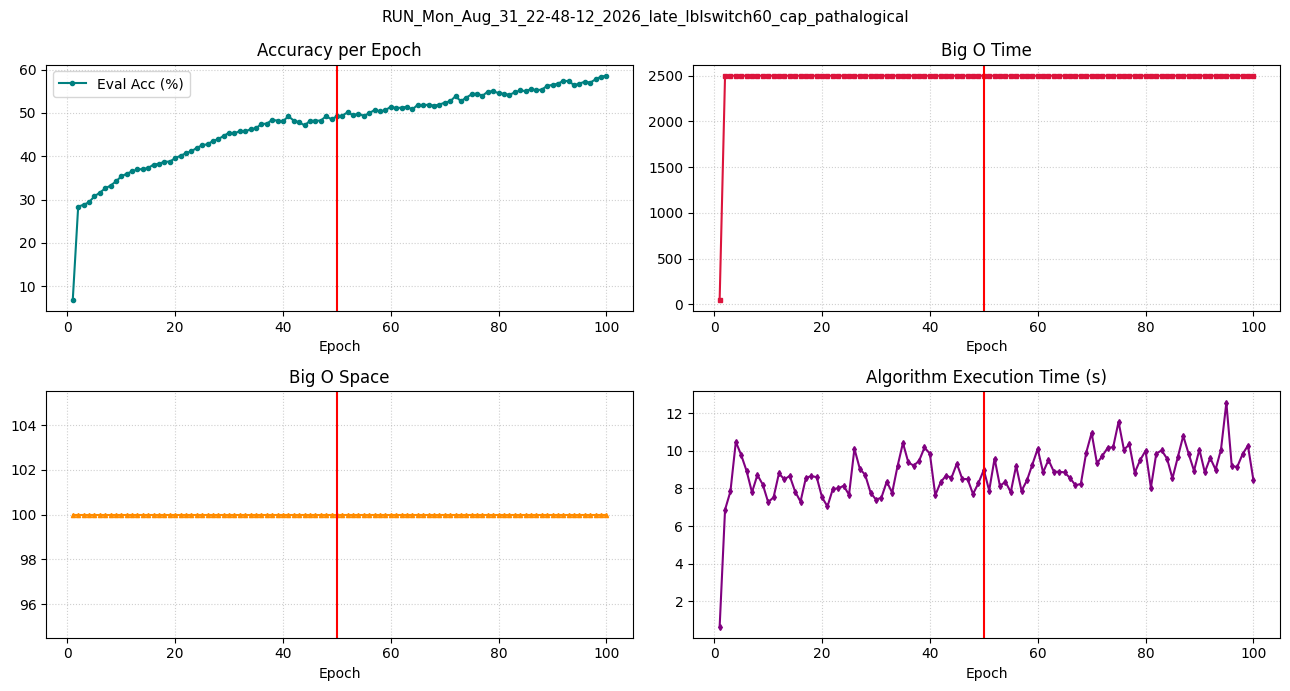

In [168]:
res1 = analyze_run(attack="late_labelswitch60", protocol="fedattract", data_type="pathalogical")
res2 = analyze_run(attack="late_labelswitch60", protocol="cap", data_type="pathalogical")

In [102]:
analyze_run(attack="majoritybyz60", protocol="fedattract", data_type="d1", return_only='bigo')

0      50
1      50
2      50
3      50
4      50
     ... 
95     62
96     62
97     62
98     62
99    714
Name: bigo_time, Length: 100, dtype: int64